# Tests GH 25-06 data reader and time series checker

This notebook reads the CSV files from `Tests GH 25-06`, parses the LoRa export format, synchronizes manual group windows with the CSV timestamps when needed, checks mapping quality, and plots RSSI/SNR through time for visual inspection.


In [125]:
# If you run this in Google Colab, authentication is handled in the next cell.
# If you run locally with downloaded CSVs, set LOCAL_DATA_DIR in the config cell.

from __future__ import annotations

import io
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import plotly.graph_objects as go
from plotly.subplots import make_subplots

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 180)
plt.style.use("seaborn-v0_8-whitegrid")


In [ ]:
# ---- Configuration ----

DRIVE_FOLDER_ID = "1Egq_nPkzHTInTvNQbOo5O5w5wvAbIAec"  # Tests GH 25-06
LOCAL_DATA_DIR = "D:/Users/user/Documents/GatewayPlacement/TestsGH2506"
ONLY_CSV_FILES = True
CACHE_DIR = Path("data_cache/tests_gh_25_06")
MANUAL_TIME_RANGES_PATH = Path("manual_time_ranges.json")
MESSAGE_SIZE_BYTES = 34

# A normal group starts a few seconds before its registered manual start.
# It ends a few seconds before the next registered manual start.
START_BEFORE_REGISTERED_SECONDS = 3
END_BEFORE_NEXT_START_SECONDS = 3
PLOT_JSON_TIME_MARGIN_SECONDS = 10
JSON_START_PLOT_REDLINE_SECONDS = 3

# Extra tail groups are only expected for these structures.
# A tail starts after a large quiet gap following the last packet of the final normal group.
EXPECTED_EXTRA_TAIL_STRUCTURES = {"R1183", "R1185", "R1356", "R1358", "R1360"}
EXTRA_TAIL_GAP_SECONDS = 60
BETWEEN_GROUP_GAP_BAR_WIDTH_SECONDS = 10
BETWEEN_GROUP_GAP_NEIGHBORS = 1
BETWEEN_GROUP_GAP_ALERT_SECONDS = 10

# Apply these explicit corrections to the manual JSON times before mapping.
# Positive values move the manual window later. All structures not listed use 0 s.
MANUAL_TIME_OFFSETS_SECONDS = {
    "R1358": -32,
    "R1183": -32,
    "R1360": -32,
}

# QC expected group counts are derived from the generated windows below.


In [127]:
def running_in_colab() -> bool:
    try:
        import google.colab  # type: ignore
        return True
    except Exception:
        return False


def build_drive_service():
    """Create an authenticated Google Drive v3 service in Colab or a local env."""
    try:
        from googleapiclient.discovery import build
        from googleapiclient.http import MediaIoBaseDownload
    except Exception as exc:
        raise RuntimeError(
            "Missing Google API packages. In Colab they are usually available. "
            "Locally, install google-api-python-client google-auth google-auth-oauthlib."
        ) from exc

    if running_in_colab():
        from google.colab import auth  # type: ignore
        auth.authenticate_user()
        import google.auth
        creds, _ = google.auth.default()
        return build("drive", "v3", credentials=creds), MediaIoBaseDownload

    # Local fallback: use Application Default Credentials if configured with gcloud auth application-default login.
    import google.auth
    creds, _ = google.auth.default(scopes=["https://www.googleapis.com/auth/drive.readonly"])
    return build("drive", "v3", credentials=creds), MediaIoBaseDownload


def list_drive_csv_files(folder_id: str) -> pd.DataFrame:
    service, _ = build_drive_service()
    rows = []
    page_token = None
    query = f"'{folder_id}' in parents and trashed = false"
    if ONLY_CSV_FILES:
        query += " and mimeType = 'text/csv'"
    while True:
        resp = service.files().list(
            q=query,
            fields="nextPageToken, files(id, name, mimeType, size, createdTime, modifiedTime)",
            orderBy="modifiedTime",
            pageSize=1000,
            pageToken=page_token,
            supportsAllDrives=True,
            includeItemsFromAllDrives=True,
        ).execute()
        rows.extend(resp.get("files", []))
        page_token = resp.get("nextPageToken")
        if not page_token:
            break
    return pd.DataFrame(rows)


def download_drive_file_text(file_id: str) -> str:
    service, MediaIoBaseDownload = build_drive_service()
    request = service.files().get_media(fileId=file_id, supportsAllDrives=True)
    fh = io.BytesIO()
    downloader = MediaIoBaseDownload(fh, request)
    done = False
    while not done:
        _, done = downloader.next_chunk()
    return fh.getvalue().decode("utf-8-sig", errors="replace")


def load_file_catalog() -> pd.DataFrame:
    if LOCAL_DATA_DIR:
        paths = sorted(Path(LOCAL_DATA_DIR).glob("*.csv"))
        return pd.DataFrame({
            "id": [None] * len(paths),
            "name": [p.name for p in paths],
            "path": [str(p) for p in paths],
            "mimeType": ["text/csv"] * len(paths),
            "modifiedTime": [pd.Timestamp(p.stat().st_mtime, unit="s").isoformat() for p in paths],
        })
    return list_drive_csv_files(DRIVE_FOLDER_ID)


def read_file_text(row: pd.Series) -> str:
    if LOCAL_DATA_DIR:
        return Path(row["path"]).read_text(encoding="utf-8-sig", errors="replace")

    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    cache_path = CACHE_DIR / f"{row['id']}_{row['name']}"
    if cache_path.exists():
        return cache_path.read_text(encoding="utf-8-sig", errors="replace")
    text = download_drive_file_text(row["id"])
    cache_path.write_text(text, encoding="utf-8")
    return text

In [128]:
def parse_filename_metadata(name: str) -> dict:
    stem = Path(name).stem
    ids = [int(x) for x in re.findall(r"(?<!\d)(\d{3,5})(?!\d)", stem)]
    primary_id = ids[0] if ids else None
    mirror_match = re.search(r"mirror\s*([0-9]{3,5})", stem, flags=re.I)
    mirror_id = int(mirror_match.group(1)) if mirror_match else None
    date_match = re.search(r"(\d{1,2})[-_](\d{1,2})", stem)
    test_date_hint = None
    if date_match:
        test_date_hint = f"2026-{int(date_match.group(2)):02d}-{int(date_match.group(1)):02d}"
    return {
        "file_stem": stem,
        "primary_id": primary_id,
        "mirror_id": mirror_id,
        "test_date_hint": test_date_hint,
    }


def parse_details(details: object) -> dict:
    if pd.isna(details):
        return {}
    parsed = {}
    for line in str(details).splitlines():
        if ":" not in line:
            continue
        key, value = line.split(":", 1)
        key = key.strip().lower().replace(" ", "_").replace("/", "_").replace("(", "").replace(")", "")
        parsed[f"detail_{key}"] = value.strip()
    return parsed


def parse_detail_json(value: object):
    if pd.isna(value) or not str(value).strip():
        return None
    raw = str(value).strip()
    try:
        return json.loads(raw)
    except Exception:
        try:
            return json.loads(raw.replace('""', '"'))
        except Exception:
            return raw


def split_rssi_snr(series: pd.Series) -> pd.DataFrame:
    split = series.fillna("-/").astype(str).str.strip().str.split("/", n=1, expand=True)
    if split.shape[1] == 1:
        split[1] = np.nan
    return pd.DataFrame({
        "rssi": pd.to_numeric(split[0].replace({"-": np.nan, "": np.nan}), errors="coerce"),
        "snr": pd.to_numeric(split[1].replace({"-": np.nan, "": np.nan}), errors="coerce"),
    })


def parse_signal_csv(text: str, file_row: pd.Series) -> tuple[pd.DataFrame, dict]:
    df = pd.read_csv(io.StringIO(text), engine="python")
    df.columns = [c.strip() for c in df.columns]
    name = file_row.get("name", file_row.get("title", "unknown.csv"))
    meta = parse_filename_metadata(name)
    df["source_file"] = name
    df["source_id"] = file_row.get("id", None)
    for key, value in meta.items():
        df[key] = value

    df = df.rename(columns={
        "Device EUI/Group": "device_eui_group",
        "Gateway ID": "gateway_id",
        "RSSI/SNR": "rssi_snr",
        "Fcnt": "fcnt",
        "Type": "type",
        "Time": "time",
        "Details": "details",
        "Frequency": "frequency",
        "Datarate": "datarate",
        "Size": "size",
    })

    df["time"] = pd.to_datetime(df["time"], errors="coerce", utc=True)
    df["time_local"] = df["time"].dt.tz_convert("Europe/Amsterdam")
    df["fcnt"] = pd.to_numeric(df.get("fcnt"), errors="coerce")
    df["frequency"] = pd.to_numeric(df.get("frequency"), errors="coerce")
    df["size"] = pd.to_numeric(df.get("size"), errors="coerce")
    df = pd.concat([df, split_rssi_snr(df.get("rssi_snr", pd.Series(index=df.index, dtype=object)))], axis=1)

    details_df = pd.DataFrame([parse_details(x) for x in df.get("details", pd.Series(index=df.index, dtype=object))])
    if not details_df.empty:
        df = pd.concat([df.reset_index(drop=True), details_df.reset_index(drop=True)], axis=1)
    df["port"] = pd.to_numeric(df.get("detail_port"), errors="coerce")
    df["payload_hex"] = df.get("detail_payloadhex", pd.Series(index=df.index, dtype=object))
    df["detail_json_obj"] = df.get("detail_json", pd.Series(index=df.index, dtype=object)).apply(parse_detail_json)
    df["gpio_in_2"] = df["detail_json_obj"].apply(lambda x: x.get("gpio_in_2") if isinstance(x, dict) else np.nan)
    df["message_text"] = df["detail_json_obj"].apply(lambda x: x.get("text") if isinstance(x, dict) else None)

    parse_info = {
        "measurable_uplink_rows": int((df["time"].notna() & df["rssi"].notna() & df["snr"].notna() & df["type"].astype(str).str.contains("Up", case=False, na=False)).sum())
    }
    return df.sort_values("time"), parse_info

In [129]:
catalog = load_file_catalog()
catalog = catalog.sort_values("modifiedTime", na_position="last").reset_index(drop=True)
catalog

,id,name,path,mimeType,modifiedTime
0,None,25-6_r1354.csv,D:\Users\user\Documents\GatewayPlacement\Tests...,text/csv,2026-06-25T00:03:18
1,None,25-6_r1356.csv,D:\Users\user\Documents\GatewayPlacement\Tests...,text/csv,2026-06-25T00:33:38
2,None,25-6_1185(mirror1356).csv,D:\Users\user\Documents\GatewayPlacement\Tests...,text/csv,2026-06-25T01:03:10
3,None,25-06_1187 (mirror 1354).csv,D:\Users\user\Documents\GatewayPlacement\Tests...,text/csv,2026-06-25T01:30:06
4,None,25-06_1189 (mirror 1352).csv,D:\Users\user\Documents\GatewayPlacement\Tests...,text/csv,2026-06-25T01:54:06
5,None,25-06_1352.csv,D:\Users\user\Documents\GatewayPlacement\Tests...,text/csv,2026-06-25T02:14:30
6,None,25-06-r1358.csv,D:\Users\user\Documents\GatewayPlacement\Tests...,text/csv,2026-06-25T02:39:50
7,None,25-6-r1183(mirror1385).csv,D:\Users\user\Documents\GatewayPlacement\Tests...,text/csv,2026-06-25T02:58:50
8,None,25-06-r1360.csv,D:\Users\user\Documents\GatewayPlacement\Tests...,text/csv,2026-06-25T03:25:52


In [130]:
frames = []
segment_reports = []

for _, row in catalog.iterrows():
    text = read_file_text(row)
    df_one, seg_info = parse_signal_csv(text, row)
    frames.append(df_one)
    segment_reports.append({
        "source_file": row.get("name", row.get("title", "unknown.csv")),
        "rows": len(df_one),
        "uplink_rows": int(df_one["type"].astype(str).str.contains("Up", case=False, na=False).sum()),
        "measurable_rows": int(df_one[["rssi", "snr"]].notna().all(axis=1).sum()),
        "first_time": df_one["time_local"].min(),
        "last_time": df_one["time_local"].max(),
        **seg_info,
    })

raw_loaded_data = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

# Keep only the measurement packets with the expected payload size.
# All mapping, summaries, and plots below use this filtered data.
data = raw_loaded_data[raw_loaded_data["size"].eq(MESSAGE_SIZE_BYTES)].copy()
segment_report = pd.DataFrame(segment_reports)
segment_report[f"rows_size_{MESSAGE_SIZE_BYTES}"] = segment_report["source_file"].map(data.groupby("source_file").size()).fillna(0).astype(int)
segment_report

,source_file,rows,uplink_rows,measurable_rows,first_time,last_time,measurable_uplink_rows,rows_size_34
0,25-6_r1354.csv,156,154,154,2026-06-25 10:06:57+02:00,2026-06-25 11:02:50+02:00,154,84
1,25-6_r1356.csv,128,127,127,2026-06-25 11:06:50+02:00,2026-06-25 11:28:27+02:00,127,65
2,25-6_1185(mirror1356).csv,205,204,204,2026-06-25 11:37:32+02:00,2026-06-25 12:00:42+02:00,204,106
3,25-06_1187 (mirror 1354).csv,144,143,143,2026-06-25 12:08:08+02:00,2026-06-25 12:26:18+02:00,143,66
4,25-06_1189 (mirror 1352).csv,126,126,126,2026-06-25 12:34:13+02:00,2026-06-25 12:46:46+02:00,126,61
5,25-06_1352.csv,137,136,136,2026-06-25 12:55:45+02:00,2026-06-25 13:10:01+02:00,136,70
6,25-06-r1358.csv,173,172,172,2026-06-25 13:19:46+02:00,2026-06-25 13:38:31+02:00,172,89
7,25-6-r1183(mirror1385).csv,138,137,137,2026-06-25 13:41:12+02:00,2026-06-25 13:56:01+02:00,137,80
8,25-06-r1360.csv,193,192,192,2026-06-25 14:03:55+02:00,2026-06-25 14:24:52+02:00,192,90


In [131]:
file_summary = (
    data.groupby(["source_file", "primary_id", "mirror_id"], dropna=False)
    .agg(
        rows=("source_file", "size"),
        first_time=("time_local", "min"),
        last_time=("time_local", "max"),
        uplink_rows=("type", lambda s: s.astype(str).str.contains("Up", case=False, na=False).sum()),
        rssi_median=("rssi", "median"),
        snr_median=("snr", "median"),
    )
    .reset_index()
)
file_summary


,source_file,primary_id,mirror_id,rows,first_time,last_time,uplink_rows,rssi_median,snr_median
0,25-06-r1358.csv,1358,NaN,89,2026-06-25 13:19:50+02:00,2026-06-25 13:38:27+02:00,89,-89.0,10.5
1,25-06-r1360.csv,1360,NaN,90,2026-06-25 14:04:00+02:00,2026-06-25 14:24:32+02:00,90,-88.0,10.0
2,25-06_1187 (mirror 1354).csv,1187,1354.0,66,2026-06-25 12:08:14+02:00,2026-06-25 12:22:37+02:00,66,-94.0,9.2
3,25-06_1189 (mirror 1352).csv,1189,1352.0,61,2026-06-25 12:34:18+02:00,2026-06-25 12:46:17+02:00,61,-94.0,8.8
4,25-06_1352.csv,1352,NaN,70,2026-06-25 12:55:48+02:00,2026-06-25 13:09:29+02:00,70,-94.0,9.1
5,25-6-r1183(mirror1385).csv,1183,1385.0,80,2026-06-25 13:41:16+02:00,2026-06-25 13:55:51+02:00,80,-92.0,9.8
6,25-6_1185(mirror1356).csv,1185,1356.0,106,2026-06-25 11:37:36+02:00,2026-06-25 12:00:31+02:00,106,-97.0,6.8
7,25-6_r1354.csv,1354,NaN,84,2026-06-25 10:07:23+02:00,2026-06-25 11:02:46+02:00,84,-89.5,9.5
8,25-6_r1356.csv,1356,NaN,65,2026-06-25 11:06:54+02:00,2026-06-25 11:25:11+02:00,65,-86.0,10.5


In [132]:
def format_time_axis(ax, left_time=None, show_left_hour=False):
    """Show one tick per minute, with the hour shown once at the left."""
    ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%M"))
    ax.tick_params(axis="x", rotation=0)
    ax.grid(False, axis="x", which="both")

    if show_left_hour and pd.notna(left_time):
        ax.text(
            -0.015,
            -0.18,
            pd.Timestamp(left_time).strftime("%H:"),
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=9,
            color="0.25",
            clip_on=False,
        )


def add_gap_bar_row(rows: list[dict], start_time, end_time, from_group, to_group, gap_role: str):
    """Add one fixed-width bar row for a positive time interval."""
    if pd.isna(start_time) or pd.isna(end_time):
        return
    gap_s = (end_time - start_time).total_seconds()
    if not np.isfinite(gap_s) or gap_s <= 0:
        return

    # Use a fixed, readable visual width for every bar. The height still
    # represents the real time between the two points.
    width_s = BETWEEN_GROUP_GAP_BAR_WIDTH_SECONDS
    center_time = start_time + (end_time - start_time) / 2
    rows.append({
        "from_group": from_group,
        "to_group": to_group,
        "gap_role": gap_role,
        "gap_start_time": start_time,
        "gap_end_time": end_time,
        "center_time": center_time,
        "center_num": mdates.date2num(center_time.to_pydatetime()),
        "bar_start_time": center_time - pd.Timedelta(seconds=width_s / 2),
        "bar_end_time": center_time + pd.Timedelta(seconds=width_s / 2),
        "width_s": width_s,
        "width_days": width_s / 86400,
        "gap_s": gap_s,
    })


def between_group_gap_table(df: pd.DataFrame, windows: pd.DataFrame) -> pd.DataFrame:
    """Measure the main group gap plus two neighboring packet gaps on each side.

    For a central gap such as 8 -> 12, this also keeps 3 -> 5, 5 -> 8,
    12 -> 20, and 20 -> 30, while ignoring farther intervals.
    Extra tail groups are not included.
    """
    if df.empty or windows.empty:
        return pd.DataFrame()

    normal_windows = windows[
        windows["has_complete_window"]
        & ~windows["is_extra_tail_group"]
        & windows["start_time"].notna()
    ].sort_values("manual_group")

    normal_points = df[
        df["manual_group_reliable"]
        & ~df["is_extra_tail_group"]
        & df["manual_group"].notna()
        & df["time_local"].notna()
    ].copy()
    if normal_windows.empty or normal_points.empty:
        return pd.DataFrame()

    all_times = normal_points["time_local"].dropna().drop_duplicates().sort_values().reset_index(drop=True)
    rows = []
    seen = set()

    for (_, current), (_, nxt) in zip(normal_windows.iloc[:-1].iterrows(), normal_windows.iloc[1:].iterrows()):
        current_group = int(current["manual_group"])
        next_group = int(nxt["manual_group"])
        current_points = normal_points[normal_points["manual_group"].astype("Int64") == current_group]
        if current_points.empty:
            continue

        last_point = current_points["time_local"].max()
        next_start = nxt["start_time"]

        previous_times = all_times[all_times < last_point].tail(BETWEEN_GROUP_GAP_NEIGHBORS).tolist()
        next_times = all_times[all_times > next_start].head(BETWEEN_GROUP_GAP_NEIGHBORS).tolist()
        local_times = previous_times + [last_point, next_start] + next_times

        for position, (left, right) in enumerate(zip(local_times[:-1], local_times[1:])):
            role = "main" if left == last_point and right == next_start else "context"
            key = (pd.Timestamp(left).value, pd.Timestamp(right).value, role)
            if key in seen:
                continue
            seen.add(key)
            add_gap_bar_row(rows, left, right, current_group, next_group, role)

    return pd.DataFrame(rows)


def draw_between_group_gap_bars(ax, df: pd.DataFrame, windows: pd.DataFrame):
    """Overlay fixed-width quiet-time bars on the RSSI plot using a right-side seconds scale."""
    gaps = between_group_gap_table(df, windows)
    if gaps.empty:
        return None

    gap_ax = ax.twinx()
    gaps = gaps.copy()
    context = gaps[gaps["gap_role"] == "context"]
    main = gaps[gaps["gap_role"] == "main"]

    if not context.empty:
        gap_ax.bar(
            context["center_num"],
            context["gap_s"],
            width=context["width_days"],
            bottom=0,
            align="center",
            color=np.where(context["gap_s"] > BETWEEN_GROUP_GAP_ALERT_SECONDS, "purple", "0.50"),
            alpha=0.14,
            edgecolor="none",
            clip_on=True,
            label="nearby timing gaps",
        )
    if not main.empty:
        gap_ax.bar(
            main["center_num"],
            main["gap_s"],
            width=main["width_days"],
            bottom=0,
            align="center",
            color=np.where(main["gap_s"] > BETWEEN_GROUP_GAP_ALERT_SECONDS, "purple", "0.20"),
            alpha=0.28,
            edgecolor="none",
            clip_on=True,
            label="between-group quiet time",
        )

    gap_ax.set_ylim(0, max(10, gaps["gap_s"].max() * 1.20))
    gap_ax.set_ylabel("Gap (s)", color="0.25")
    gap_ax.tick_params(axis="y", colors="0.25", labelsize=8)
    gap_ax.grid(False)
    return gap_ax

def plot_file_timeseries(df: pd.DataFrame, file_name: str, group_col: str = "manual_group"):
    one = df[df["source_file"] == file_name].sort_values("time_local").copy()
    measured = one[one["type"].astype(str).str.contains("Up", case=False, na=False)]
    if measured.empty:
        print(f"No uplink measurements for {file_name}")
        return

    fig, axes = plt.subplots(2, 1, figsize=(15, 6.8), sharex=True)
    fig.suptitle(file_name, y=0.98, fontsize=14)

    if group_col in measured.columns:
        for _, chunk in measured.dropna(subset=[group_col]).groupby(group_col):
            if chunk.empty:
                continue
            for ax in axes:
                ax.axvspan(chunk["time_local"].min(), chunk["time_local"].max(), alpha=0.055, color="tab:blue")

    # Use one calm point style; group boundaries already show the mapping.
    axes[0].scatter(measured["time_local"], measured["rssi"], s=24, color="tab:blue", alpha=0.82)
    axes[1].scatter(measured["time_local"], measured["snr"], s=24, color="tab:green", alpha=0.82)

    axes[0].set_ylabel("RSSI (dBm)")
    axes[1].set_ylabel("SNR (dB)")
    axes[1].set_xlabel("Minute, Europe/Amsterdam")
    left_time = measured["time_local"].min()
    for ax in axes:
        format_time_axis(ax)
    format_time_axis(axes[-1], left_time=left_time, show_left_hour=True)
    plt.tight_layout()
    plt.show()


# Raw per-file plotting helper. Run manually after manual assignment if needed:
# plot_file_timeseries(data, catalog["name"].iloc[0])


## Manual Time Mapping

Each manual group starts at the time written in `manual_time_ranges.json`, after applying any explicit structure offset. A packet belongs to group `Gk` when it is between `Gk` start and 8 seconds before `G{k+1}` starts. Everything after the last registered manual time is assigned to a final open-ended group.


In [133]:
MANUAL_CONFIG = json.loads(MANUAL_TIME_RANGES_PATH.read_text(encoding="utf-8"))
TEST_DATE = "2026-06-25"
LOCAL_TZ = "Europe/Amsterdam"


def hhmmss_to_timestamp(value, date=TEST_DATE, tz=LOCAL_TZ):
    """Convert a manual HH:MM:SS value into a timezone-aware timestamp."""
    if value is None or pd.isna(value):
        return pd.NaT
    return pd.Timestamp(f"{date} {value}", tz=tz)


def structure_from_row(row: pd.Series) -> str | None:
    """Get the structure id from the filename metadata already parsed from the CSV name."""
    value = row.get("primary_id")
    if pd.isna(value):
        value = row.get("mirror_id")
    if pd.isna(value):
        return None
    return f"R{int(value)}"


def manual_offset_for(structure_id: str) -> pd.Timedelta:
    """Return the explicit time correction for a structure's manual timestamps."""
    return pd.Timedelta(seconds=MANUAL_TIME_OFFSETS_SECONDS.get(structure_id, 0))


def manual_ranges_to_frame(config: dict) -> pd.DataFrame:
    """Flatten the manual JSON ranges and apply the configured structure offsets."""
    rows = []
    for key, (start, next_start) in config["ranges"].items():
        structure, group = key.split("_G", 1)
        offset = manual_offset_for(structure)
        manual_start = hhmmss_to_timestamp(start)
        manual_next_start = hhmmss_to_timestamp(next_start)
        registered_start = manual_start + offset if pd.notna(manual_start) else pd.NaT
        registered_next_start = manual_next_start + offset if pd.notna(manual_next_start) else pd.NaT
        rows.append({
            "range_key": key,
            "structure_id": structure,
            "manual_group": int(group),
            "manual_offset_s": offset.total_seconds(),
            "start_raw": start,
            "next_start_raw": next_start,
            "manual_start_time": manual_start,
            "manual_next_start_time": manual_next_start,
            "registered_start_time": registered_start,
            "start_time": registered_start - pd.Timedelta(seconds=START_BEFORE_REGISTERED_SECONDS) if pd.notna(registered_start) else pd.NaT,
            "next_start_time": registered_next_start,
        })
    ranges = pd.DataFrame(rows).sort_values(["structure_id", "manual_group"]).reset_index(drop=True)
    ranges["manual_duration_to_next_s"] = (ranges["manual_next_start_time"] - ranges["manual_start_time"]).dt.total_seconds()
    return ranges


raw_data = data.copy()
raw_data["structure_id"] = raw_data.apply(structure_from_row, axis=1)
manual_ranges = manual_ranges_to_frame(MANUAL_CONFIG)

# This table is only for inspection: it shows which structures were shifted.
offset_report = (
    manual_ranges[["structure_id", "manual_offset_s"]]
    .drop_duplicates()
    .sort_values("structure_id")
    .reset_index(drop=True)
)
offset_report


,structure_id,manual_offset_s
0,R1181,0.0
1,R1183,-32.0
2,R1185,0.0
3,R1187,0.0
4,R1189,0.0
5,R1352,0.0
6,R1354,0.0
7,R1356,0.0
8,R1358,-32.0
9,R1360,-32.0


In [134]:
def find_final_group_cutoffs(packet_data: pd.DataFrame, structure_id: str, final_start):
    """Find where the final normal group ends and where an expected extra tail begins.

    The tail rule is based on the data itself: first collect the final normal group,
    then start an extra group only after a quiet gap of at least EXTRA_TAIL_GAP_SECONDS.
    Structures not listed in EXPECTED_EXTRA_TAIL_STRUCTURES never produce an extra tail group.
    """
    packets = packet_data[
        (packet_data["structure_id"] == structure_id)
        & (packet_data["time_local"] >= final_start)
        & packet_data["type"].astype(str).str.contains("Up", case=False, na=False)
    ].sort_values("time_local")
    times = packets["time_local"].dropna().reset_index(drop=True)
    if times.empty:
        return pd.NaT, pd.NaT

    if len(times) >= 2:
        gaps_s = times.diff().dt.total_seconds()
        gap_candidates = gaps_s[gaps_s >= EXTRA_TAIL_GAP_SECONDS]
        if not gap_candidates.empty:
            gap_index = gap_candidates.index[0]
            last_normal_packet = times.iloc[gap_index - 1]

            # A large gap after the final JSON-defined group means the normal data ended.
            # Only explicitly expected structures keep the later points as an extra tail group;
            # otherwise they are treated as spurious and remain unmapped.
            if structure_id in EXPECTED_EXTRA_TAIL_STRUCTURES:
                extra_start = times.iloc[gap_index]
                return last_normal_packet, extra_start
            return last_normal_packet, pd.NaT

    return times.iloc[-1], pd.NaT


def split_extra_final_groups(windows: pd.DataFrame, packet_data: pd.DataFrame) -> pd.DataFrame:
    """Close final normal groups at their last contiguous packet and add expected extra tails."""
    windows = windows.copy()
    extra_rows = []

    for idx, row in windows[windows["is_final_group"]].iterrows():
        last_normal_packet, extra_start = find_final_group_cutoffs(packet_data, row["structure_id"], row["start_time"])

        if pd.notna(last_normal_packet):
            windows.loc[idx, "valid_end"] = last_normal_packet + pd.Timedelta(microseconds=1)
            windows.loc[idx, "has_complete_window"] = windows.loc[idx, "valid_end"] > windows.loc[idx, "start_time"]
        else:
            # The JSON still defines this final group even if no packet was received in it.
            # Keep a short visible window so QC/plots show the expected group count.
            windows.loc[idx, "valid_end"] = row["registered_start_time"] + pd.Timedelta(seconds=5)
            windows.loc[idx, "has_complete_window"] = windows.loc[idx, "valid_end"] > windows.loc[idx, "start_time"]

        if pd.isna(extra_start):
            continue

        # The new group is the expected extra tail and is saved separately.
        new_row = row.copy()
        new_row["range_key"] = f"{row['structure_id']}_G{int(row['manual_group']) + 1}_extra_tail"
        new_row["manual_group"] = int(row["manual_group"]) + 1
        new_row["registered_start_time"] = extra_start
        new_row["start_time"] = extra_start
        new_row["effective_next_start_time"] = pd.NaT
        new_row["valid_end"] = pd.NaT
        new_row["is_final_group"] = True
        new_row["is_extra_tail_group"] = True
        new_row["has_complete_window"] = True
        extra_rows.append(new_row)

    if extra_rows:
        windows = pd.concat([windows, pd.DataFrame(extra_rows)], ignore_index=True)
    return windows


def build_mapping_windows(ranges: pd.DataFrame, packet_data: pd.DataFrame) -> pd.DataFrame:
    """Create the time windows used for assigning CSV packets to manual groups."""
    windows = ranges.copy()
    windows["is_extra_tail_group"] = False

    # Regular groups end shortly before the next group starts.
    # If the next start is missing, use the last registered time for that structure.
    last_registered = {}
    for structure_id, group in windows.groupby("structure_id", dropna=False):
        registered = pd.concat([group["registered_start_time"], group["next_start_time"]]).dropna()
        if not registered.empty:
            last_registered[structure_id] = registered.max()

    windows["effective_next_start_time"] = windows.apply(
        lambda row: row["next_start_time"] if pd.notna(row["next_start_time"]) else last_registered.get(row["structure_id"], pd.NaT),
        axis=1,
    )
    windows["valid_end"] = windows["effective_next_start_time"].apply(
        lambda value: value - pd.Timedelta(seconds=END_BEFORE_NEXT_START_SECONDS) if pd.notna(value) else pd.NaT
    )
    windows["is_final_group"] = False
    windows["has_complete_window"] = (
        windows["start_time"].notna()
        & windows["valid_end"].notna()
        & (windows["valid_end"] > windows["start_time"])
    )

    # Add one final normal group per structure, starting at the last manual time available.
    # Its end is determined from the last contiguous packet in the CSV data.
    final_rows = []
    for structure_id, group in windows.groupby("structure_id", dropna=False):
        registered_times = pd.concat([group["registered_start_time"], group["next_start_time"]]).dropna()
        if registered_times.empty:
            continue
        final_registered_start = registered_times.max()
        final_start = final_registered_start - pd.Timedelta(seconds=START_BEFORE_REGISTERED_SECONDS)
        final_group = int(group["manual_group"].max()) + 1
        final_rows.append({
            "range_key": f"{structure_id}_G{final_group}_final",
            "structure_id": structure_id,
            "manual_group": final_group,
            "manual_offset_s": group["manual_offset_s"].dropna().iloc[0] if group["manual_offset_s"].notna().any() else 0,
            "start_raw": None,
            "next_start_raw": None,
            "manual_start_time": pd.NaT,
            "manual_next_start_time": pd.NaT,
            "registered_start_time": final_registered_start,
            "start_time": final_start,
            "next_start_time": pd.NaT,
            "effective_next_start_time": pd.NaT,
            "manual_duration_to_next_s": np.nan,
            "valid_end": pd.NaT,
            "is_final_group": True,
            "is_extra_tail_group": False,
            "has_complete_window": True,
        })

    if final_rows:
        windows = pd.concat([windows, pd.DataFrame(final_rows)], ignore_index=True)

    windows = split_extra_final_groups(windows, packet_data)

    windows["window_duration_s"] = windows.apply(
        lambda row: (row["valid_end"] - row["start_time"]).total_seconds() if pd.notna(row["valid_end"]) and pd.notna(row["start_time"]) else np.nan,
        axis=1,
    )
    windows.loc[~windows["has_complete_window"], "window_duration_s"] = np.nan
    return windows.sort_values(["structure_id", "manual_group", "is_final_group"]).reset_index(drop=True)


mapping_windows = build_mapping_windows(manual_ranges, raw_data)
mapping_windows[[
    "structure_id", "manual_group", "manual_offset_s", "start_time", "valid_end", "is_final_group", "is_extra_tail_group", "has_complete_window"
]].head(30)


,structure_id,manual_group,manual_offset_s,start_time,valid_end,is_final_group,is_extra_tail_group,has_complete_window
0,R1181,1,0.0,2026-06-25 14:46:45.900000+02:00,2026-06-25 14:46:54.900000+02:00,False,False,True
1,R1181,2,0.0,2026-06-25 14:46:54.900000+02:00,2026-06-25 14:47:46.900000+02:00,False,False,True
2,R1181,3,0.0,2026-06-25 14:47:46.900000+02:00,2026-06-25 14:48:39.900000+02:00,False,False,True
3,R1181,4,0.0,2026-06-25 14:48:39.900000+02:00,2026-06-25 14:49:11.900000+02:00,False,False,True
4,R1181,5,0.0,2026-06-25 14:49:11.900000+02:00,2026-06-25 14:50:09.900000+02:00,False,False,True
5,R1181,6,0.0,2026-06-25 14:50:09.900000+02:00,2026-06-25 14:51:39.900000+02:00,False,False,True
6,R1181,7,0.0,2026-06-25 14:51:39.900000+02:00,2026-06-25 15:31:43.900000+02:00,False,False,True
7,R1181,8,0.0,2026-06-25 15:31:43.900000+02:00,2026-06-25 15:32:33.900000+02:00,False,False,True
8,R1181,9,0.0,2026-06-25 15:32:33.900000+02:00,2026-06-25 15:33:45.900000+02:00,False,False,True
9,R1181,10,0.0,2026-06-25 15:33:45.900000+02:00,2026-06-25 15:37:13.900000+02:00,False,False,True


In [135]:
def match_manual_group(time_value, structure_id: str | None, windows: pd.DataFrame):
    """Assign one CSV timestamp to one manual group, or flag why it cannot be assigned."""
    if structure_id is None or pd.isna(structure_id):
        return pd.Series({"manual_group": pd.NA, "manual_group_status": "file_structure_unknown", "manual_group_reliable": False})
    if pd.isna(time_value):
        return pd.Series({"manual_group": pd.NA, "manual_group_status": "missing_time", "manual_group_reliable": False})

    sub = windows[(windows["structure_id"] == structure_id) & (windows["has_complete_window"])]
    if sub.empty:
        return pd.Series({"manual_group": pd.NA, "manual_group_status": "no_complete_manual_window_for_structure", "manual_group_reliable": False})

    finite = sub[sub["valid_end"].notna()]
    matches = finite[(finite["start_time"] <= time_value) & (time_value < finite["valid_end"])]

    open_tail = sub[sub["valid_end"].isna() & sub["is_extra_tail_group"]]
    if matches.empty and not open_tail.empty:
        matches = open_tail[open_tail["start_time"] <= time_value]

    if len(matches) == 1:
        status = "assigned_extra_tail" if bool(matches.iloc[0]["is_extra_tail_group"]) else "assigned_manual_window"
        return pd.Series({"manual_group": int(matches.iloc[0]["manual_group"]), "manual_group_status": status, "manual_group_reliable": True})
    if len(matches) > 1:
        groups = ",".join(matches["manual_group"].astype(str))
        return pd.Series({"manual_group": pd.NA, "manual_group_status": f"ambiguous_manual_window_overlap:{groups}", "manual_group_reliable": False})

    nearest = sub.iloc[(sub["start_time"] - time_value).abs().argsort()[:1]]
    if not nearest.empty:
        delta_s = abs((time_value - nearest.iloc[0]["start_time"]).total_seconds())
        return pd.Series({"manual_group": pd.NA, "manual_group_status": f"outside_manual_window_nearest_G{int(nearest.iloc[0]['manual_group'])}_{delta_s:.1f}s", "manual_group_reliable": False})
    return pd.Series({"manual_group": pd.NA, "manual_group_status": "outside_manual_windows", "manual_group_reliable": False})


def add_manual_groups(df: pd.DataFrame, windows: pd.DataFrame) -> pd.DataFrame:
    """Attach manual group assignments and the offset used for each structure."""
    out = df.copy()
    assigned = out.apply(lambda row: match_manual_group(row["time_local"], row["structure_id"], windows), axis=1)
    out = pd.concat([out, assigned], axis=1)
    out["manual_group"] = out["manual_group"].astype("Int64")
    out["manual_group_reliable"] = out["manual_group_reliable"].astype(bool)
    window_flags = windows[["structure_id", "manual_group", "manual_offset_s", "is_extra_tail_group"]].drop_duplicates()
    out = out.merge(window_flags, on=["structure_id", "manual_group"], how="left")
    fallback_offsets = windows[["structure_id", "manual_offset_s"]].drop_duplicates("structure_id")
    out = out.merge(fallback_offsets, on="structure_id", how="left", suffixes=("", "_fallback"))
    out["manual_offset_s"] = out["manual_offset_s"].fillna(out["manual_offset_s_fallback"])
    out["is_extra_tail_group"] = out["is_extra_tail_group"].fillna(False).astype(bool)
    out = out.drop(columns=["manual_offset_s_fallback"])
    return out


mapped_data = add_manual_groups(raw_data, mapping_windows)
data = mapped_data

manual_assignment_report = (
    mapped_data.groupby(["source_file", "structure_id", "manual_offset_s", "manual_group_status", "manual_group_reliable"], dropna=False)
    .size()
    .reset_index(name="rows")
    .sort_values(["source_file", "manual_group_reliable", "manual_group_status"], ascending=[True, False, True])
)
manual_assignment_report


C:\Users\user\AppData\Local\Temp\ipykernel_17056\2818512214.py:45: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  out["is_extra_tail_group"] = out["is_extra_tail_group"].fillna(False).astype(bool)


,source_file,structure_id,manual_offset_s,manual_group_status,manual_group_reliable,rows
0,25-06-r1358.csv,R1358,-32.0,assigned_extra_tail,True,29
1,25-06-r1358.csv,R1358,-32.0,assigned_manual_window,True,60
2,25-06-r1360.csv,R1360,-32.0,assigned_extra_tail,True,37
3,25-06-r1360.csv,R1360,-32.0,assigned_manual_window,True,53
4,25-06_1187 (mirror 1354).csv,R1187,0.0,assigned_manual_window,True,66
5,25-06_1189 (mirror 1352).csv,R1189,0.0,assigned_manual_window,True,61
6,25-06_1352.csv,R1352,0.0,assigned_manual_window,True,69
7,25-06_1352.csv,R1352,0.0,outside_manual_window_nearest_G1_1.9s,False,1
8,25-6-r1183(mirror1385).csv,R1183,-32.0,assigned_extra_tail,True,30
9,25-6-r1183(mirror1385).csv,R1183,-32.0,assigned_manual_window,True,50


In [136]:
def expected_group_counts(windows: pd.DataFrame) -> pd.DataFrame:
    """Expected groups are only the JSON-defined normal groups; extra tail groups are separate."""
    return (
        windows[~windows["is_extra_tail_group"]].groupby("structure_id", dropna=False)["manual_group"]
        .nunique()
        .reset_index(name="expected_groups")
    )


def summarize_manual_groups(df: pd.DataFrame) -> pd.DataFrame:
    """Summarize RSSI/SNR stability for every mapped structure and group."""
    measured = df[df["type"].astype(str).str.contains("Up", case=False, na=False)].copy()
    measured = measured[measured["manual_group"].notna()]
    if measured.empty:
        return pd.DataFrame()

    def mad(series):
        series = series.dropna()
        if series.empty:
            return np.nan
        return float((series - series.median()).abs().median())

    return (
        measured.groupby(["structure_id", "manual_offset_s", "manual_group", "is_extra_tail_group", "manual_group_status"], dropna=False)
        .agg(
            samples=("rssi", "count"),
            first_time=("time_local", "min"),
            last_time=("time_local", "max"),
            rssi_median=("rssi", "median"),
            rssi_mad=("rssi", mad),
            snr_median=("snr", "median"),
            snr_mad=("snr", mad),
        )
        .reset_index()
        .sort_values(["structure_id", "manual_group"])
    )


manual_group_summary = summarize_manual_groups(mapped_data)

normal_group_summary = manual_group_summary[~manual_group_summary["is_extra_tail_group"]].copy()

expected_group_report = (
    normal_group_summary.groupby("structure_id", dropna=False)
    .agg(assigned_groups=("manual_group", "nunique"), samples=("samples", "sum"))
    .reset_index()
    .merge(offset_report, on="structure_id", how="left")
)
expected_group_report = expected_group_report.merge(expected_group_counts(mapping_windows), on="structure_id", how="left")
expected_group_report["missing_groups"] = expected_group_report["expected_groups"] - expected_group_report["assigned_groups"]
expected_group_report["mapping_count_ok"] = expected_group_report["missing_groups"].eq(0)

manual_group_summary, expected_group_report


(    structure_id  manual_offset_s  manual_group  is_extra_tail_group     manual_group_status  samples                first_time                 last_time  rssi_median  rssi_mad  \
 0          R1183            -32.0             1                False  assigned_manual_window        5 2026-06-25 13:41:16+02:00 2026-06-25 13:41:53+02:00        -51.0       6.0   
 1          R1183            -32.0             2                False  assigned_manual_window        5 2026-06-25 13:42:06+02:00 2026-06-25 13:42:48+02:00        -59.0       1.0   
 2          R1183            -32.0             3                False  assigned_manual_window        5 2026-06-25 13:43:05+02:00 2026-06-25 13:43:28+02:00        -74.0       2.0   
 3          R1183            -32.0             4                False  assigned_manual_window        5 2026-06-25 13:43:57+02:00 2026-06-25 13:44:27+02:00        -93.0       2.0   
 4          R1183            -32.0             5                False  assigned_manual_window  

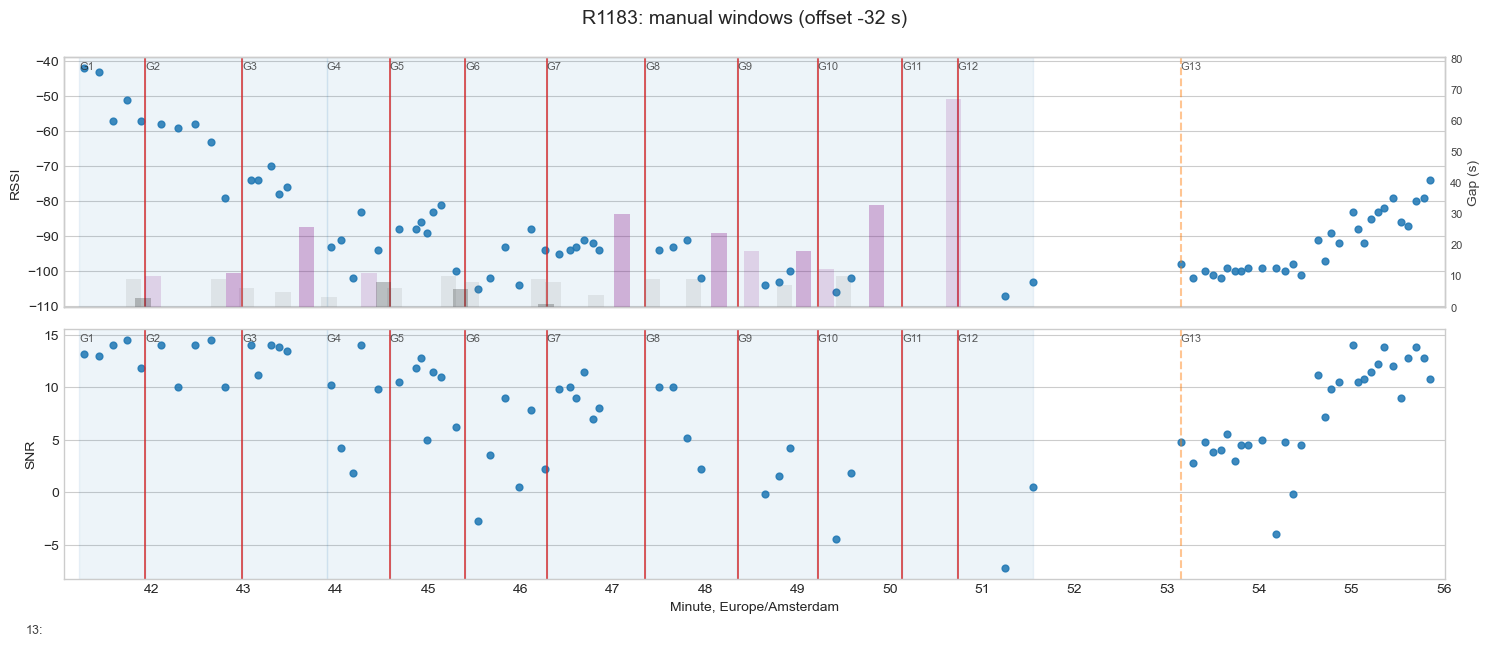

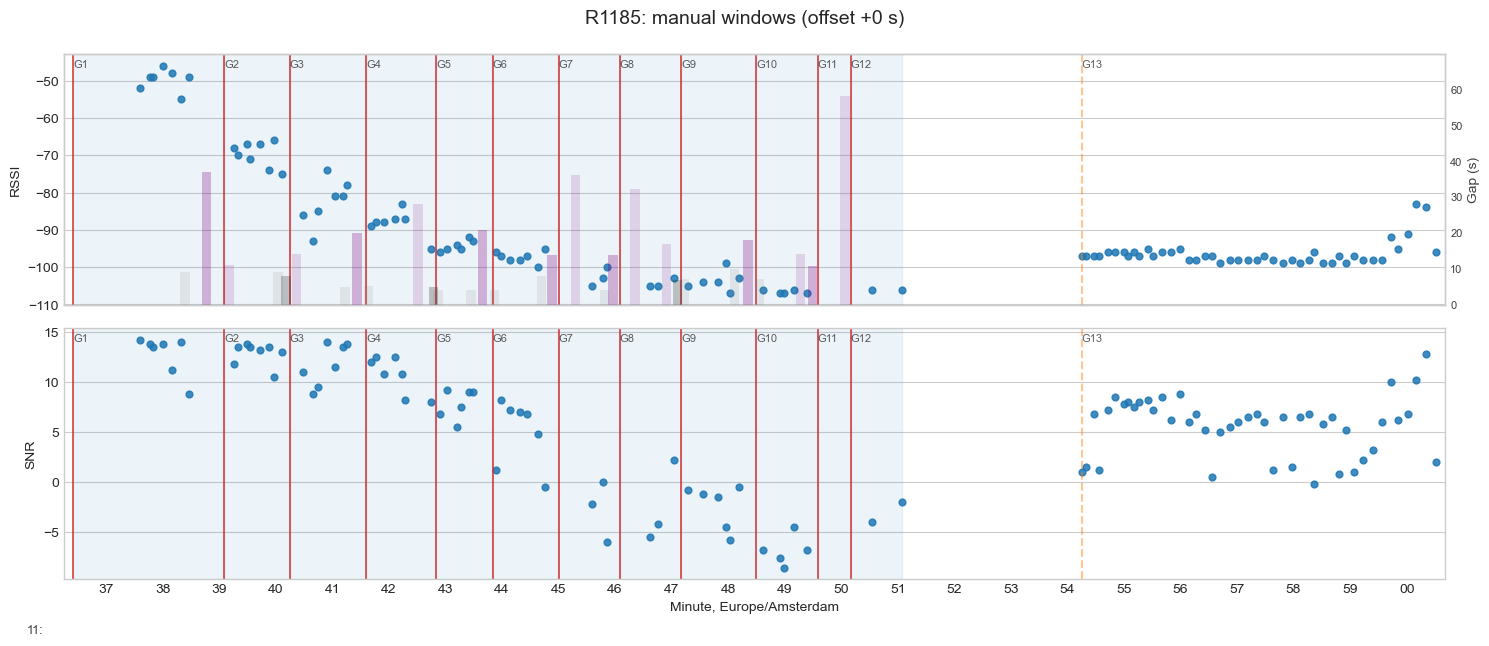

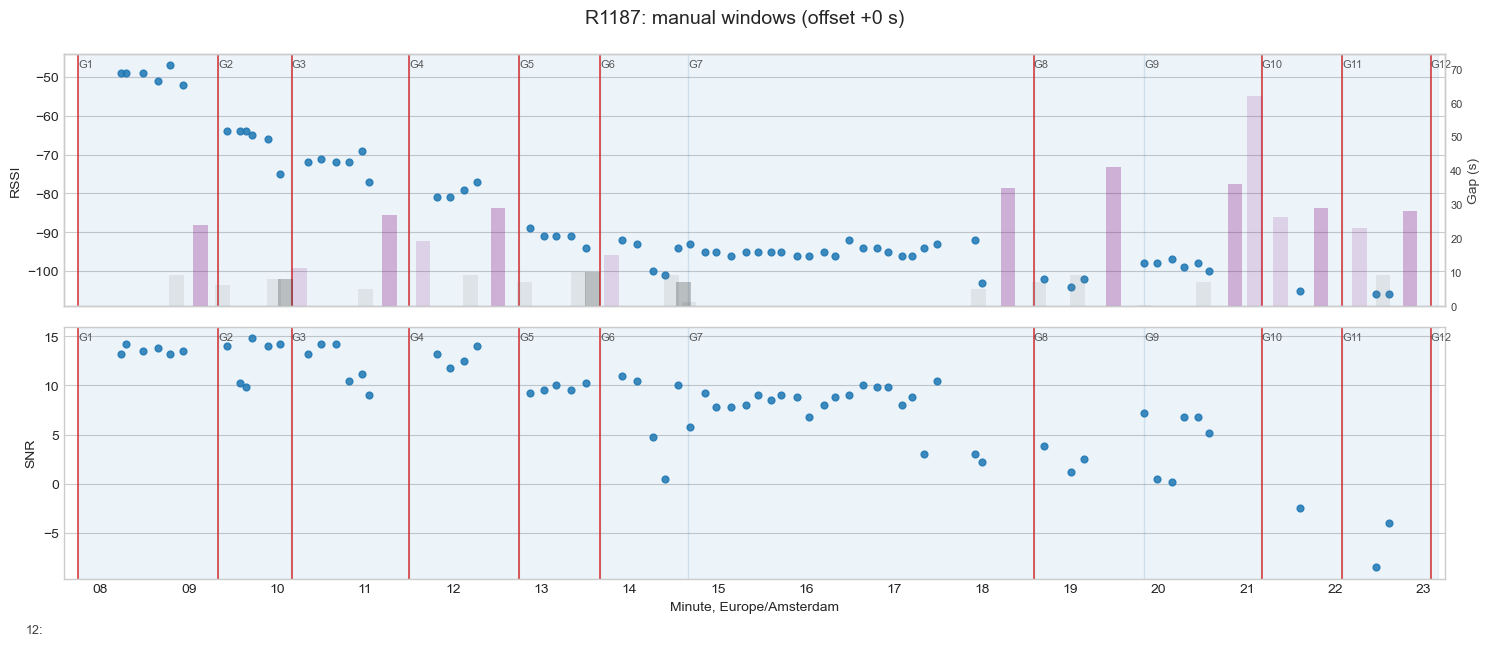

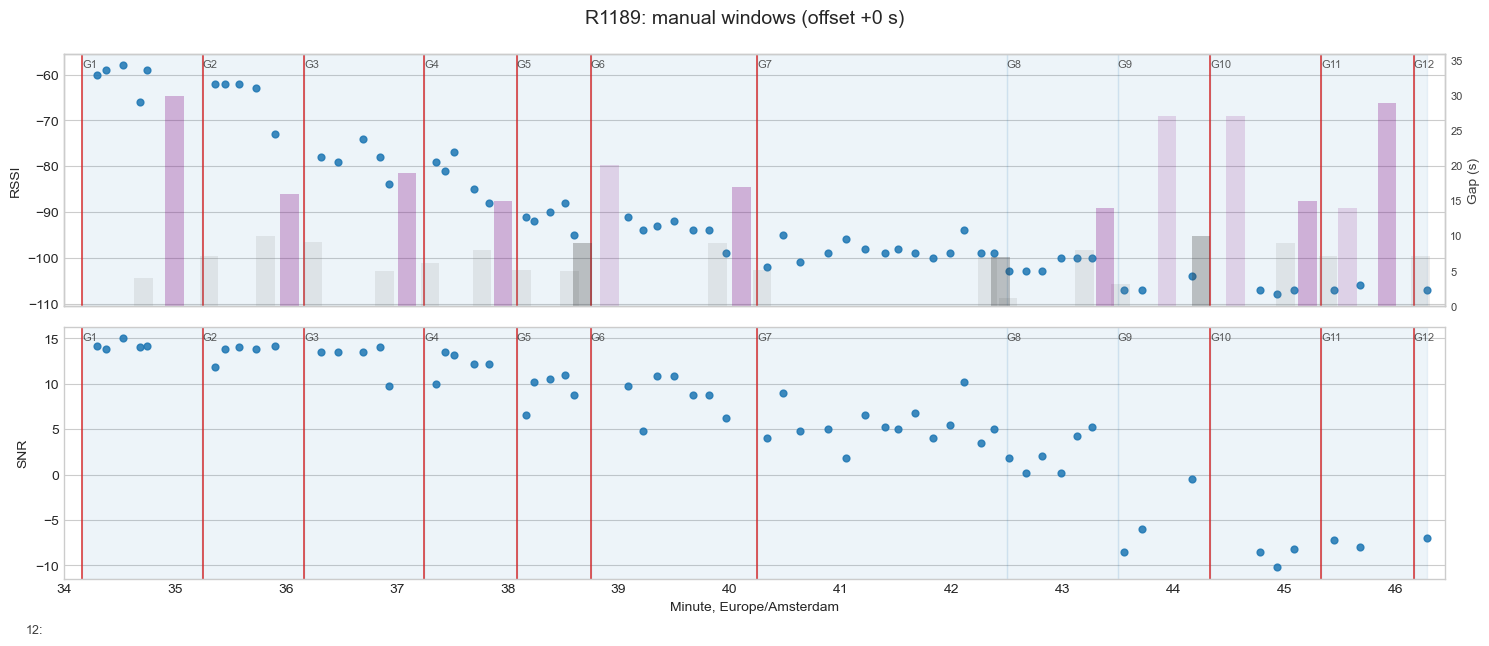

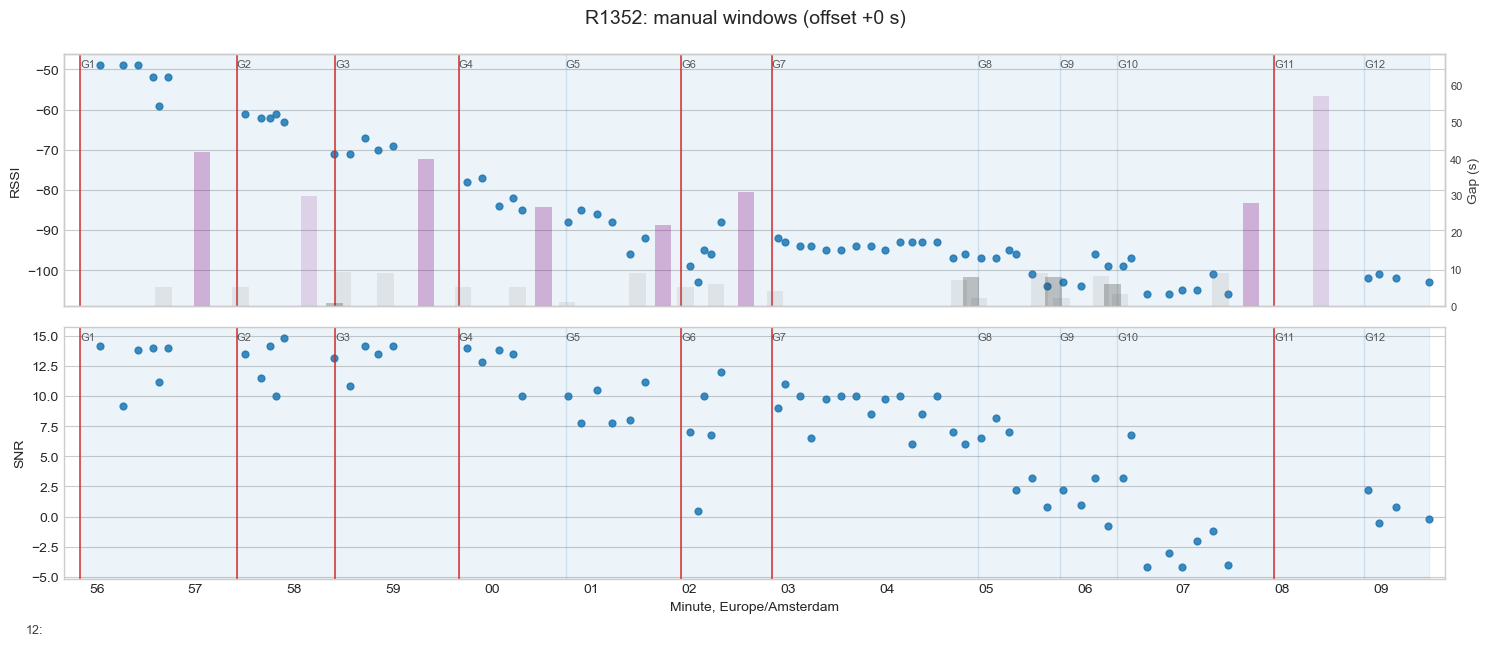

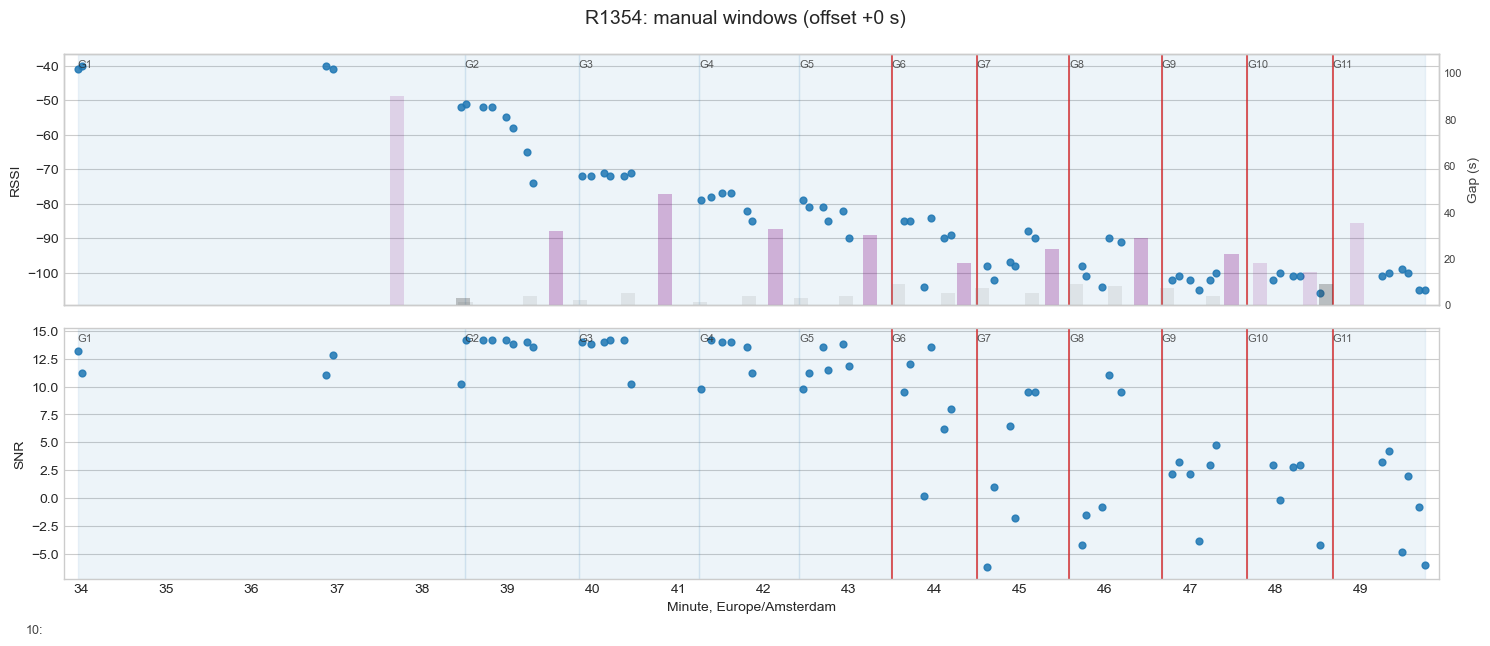

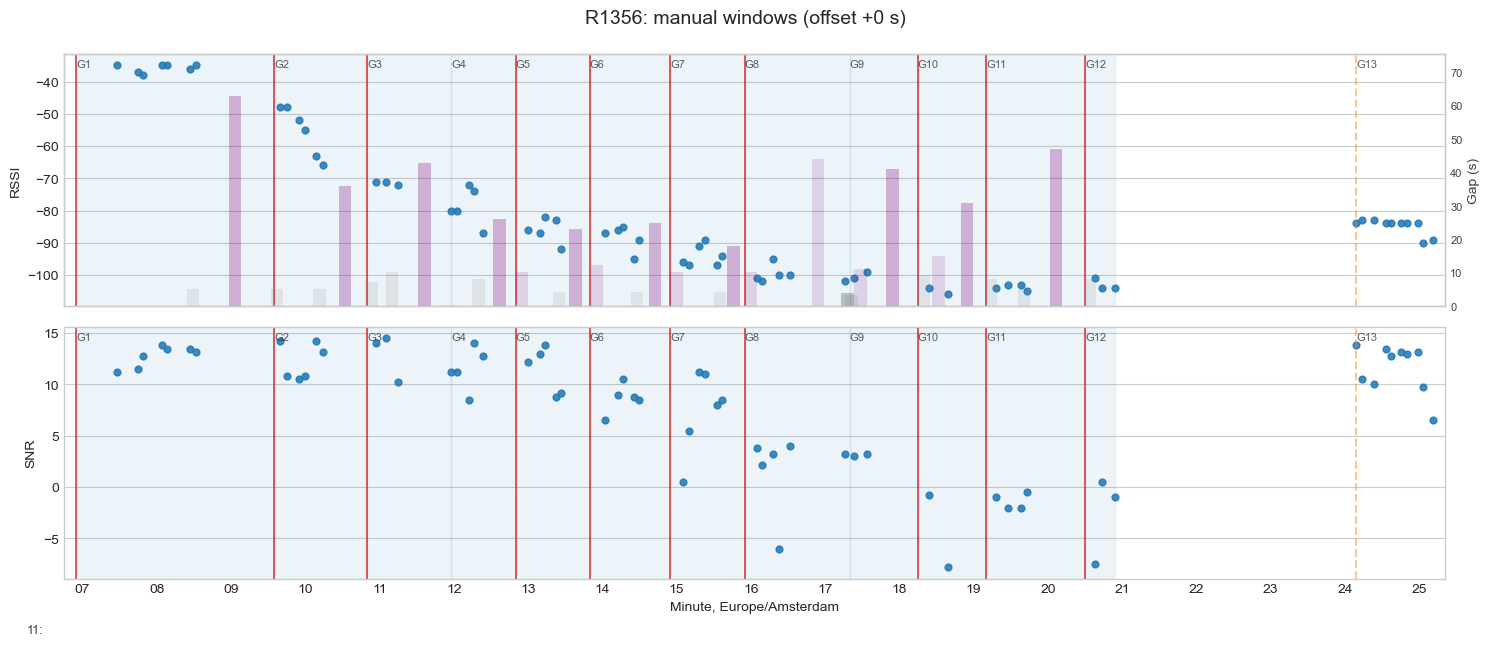

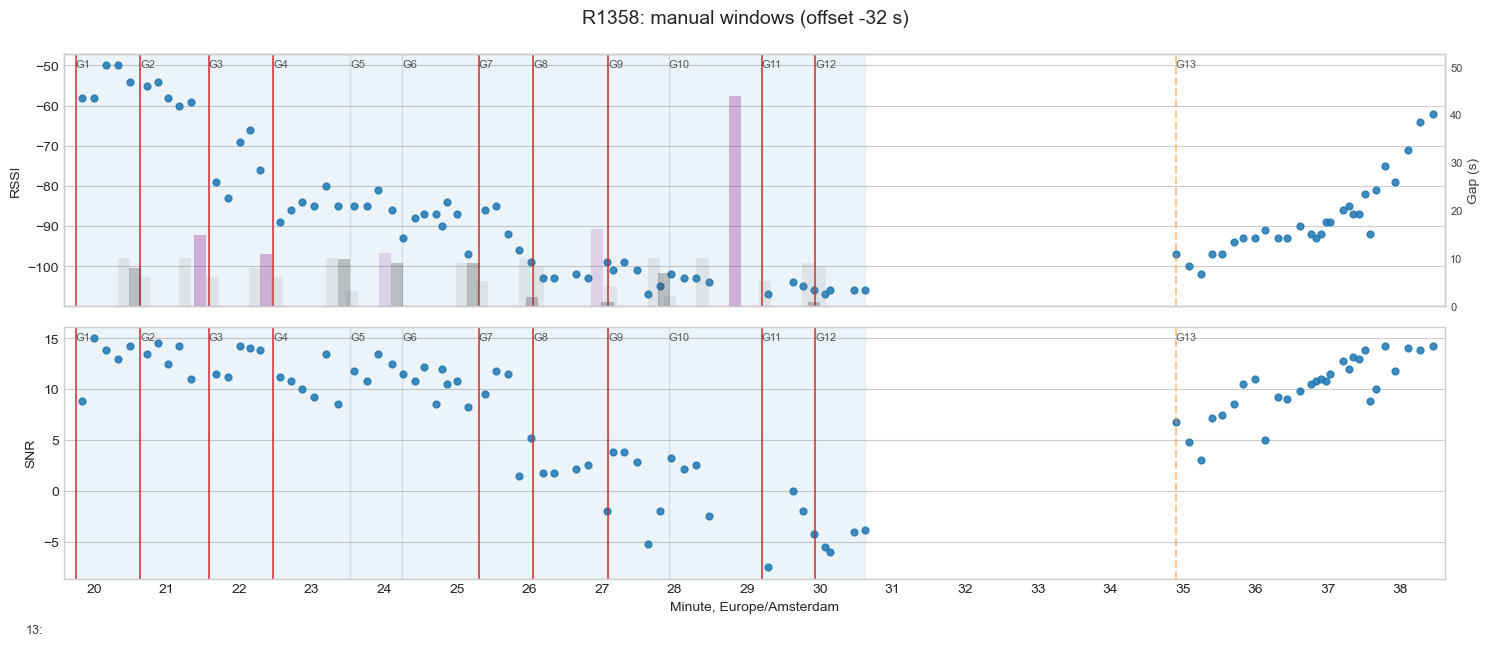

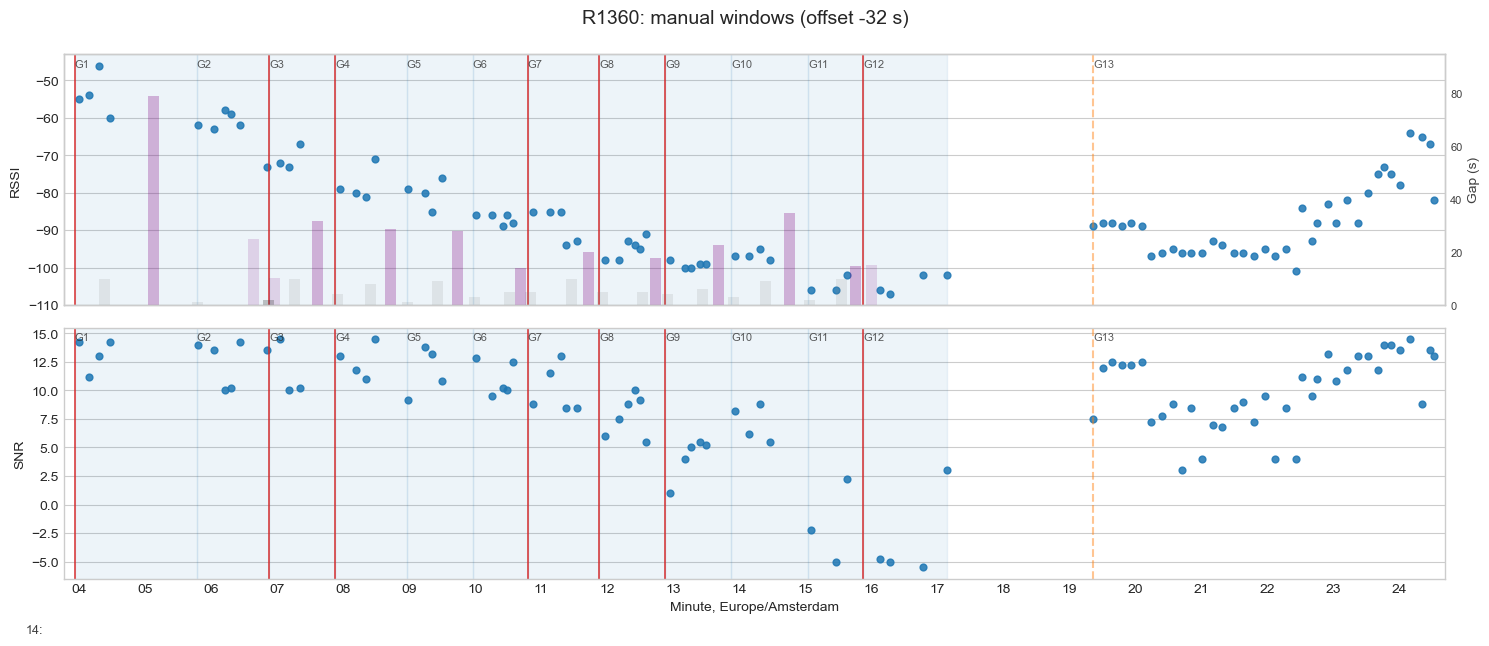

[WindowsPath('outputs/interactive_plots/R1183_manual_timeseries.html'),
 WindowsPath('outputs/interactive_plots/R1185_manual_timeseries.html'),
 WindowsPath('outputs/interactive_plots/R1187_manual_timeseries.html'),
 WindowsPath('outputs/interactive_plots/R1189_manual_timeseries.html'),
 WindowsPath('outputs/interactive_plots/R1352_manual_timeseries.html'),
 WindowsPath('outputs/interactive_plots/R1354_manual_timeseries.html'),
 WindowsPath('outputs/interactive_plots/R1356_manual_timeseries.html'),
 WindowsPath('outputs/interactive_plots/R1358_manual_timeseries.html'),
 WindowsPath('outputs/interactive_plots/R1360_manual_timeseries.html')]

In [137]:
def plot_manual_timeseries(df: pd.DataFrame, structure_id: str, metric_cols=("rssi", "snr")):
    one = df[(df["structure_id"] == structure_id) & df["type"].astype(str).str.contains("Up", case=False, na=False)].copy()
    one = one.sort_values("time_local")
    if one.empty:
        print(f"No uplink rows found for {structure_id}")
        return

    offset_s = one["manual_offset_s"].dropna().iloc[0] if one["manual_offset_s"].notna().any() else 0
    fig, axes = plt.subplots(len(metric_cols), 1, figsize=(15, 3.2 * len(metric_cols)), sharex=True)
    axes = np.atleast_1d(axes).tolist()
    fig.suptitle(f"{structure_id}: manual windows (offset {offset_s:+.0f} s)", fontsize=14, y=0.995)

    ranges = mapping_windows[mapping_windows["structure_id"] == structure_id]
    measured_times = one["time_local"].dropna().sort_values()
    for ax in axes:
        for _, rr in ranges.iterrows():
            if not bool(rr["has_complete_window"]):
                continue
            if pd.notna(rr["valid_end"]):
                color = "tab:orange" if bool(rr["is_extra_tail_group"]) else "tab:blue"
                ax.axvspan(rr["start_time"], rr["valid_end"], color=color, alpha=0.08)
            else:
                ax.axvline(rr["start_time"], color="tab:orange", alpha=0.45, linestyle="--")
            ax.text(rr["start_time"], 0.98, f"G{int(rr['manual_group'])}", transform=ax.get_xaxis_transform(), va="top", fontsize=8, alpha=0.75)

            # Mark JSON starts where the first observed packet is late or missing.
            if not bool(rr["is_extra_tail_group"]) and pd.notna(rr["registered_start_time"]):
                first_after = measured_times[measured_times >= rr["registered_start_time"]]
                late_or_missing = first_after.empty
                if not first_after.empty:
                    delta_s = (first_after.iloc[0] - rr["registered_start_time"]).total_seconds()
                    late_or_missing = delta_s > JSON_START_PLOT_REDLINE_SECONDS
                if late_or_missing:
                    ax.axvline(rr["registered_start_time"], color="tab:red", alpha=0.82, linewidth=1.3)

    reliable = one[one["manual_group_reliable"]]
    for ax, metric in zip(axes, metric_cols):
        ax.scatter(reliable["time_local"], reliable[metric], s=24, color="tab:blue", alpha=0.86, label="inside mapped window")
        ax.set_ylabel(metric.upper())

    # On the RSSI axis, overlay one bar per normal-group transition:
    # height = seconds from the last point of Gi to the start of G(i+1),
    # width = 10 s when possible, centered inside that quiet window.
    rssi_axis = axes[list(metric_cols).index("rssi")] if "rssi" in metric_cols else axes[0]
    draw_between_group_gap_bars(rssi_axis, reliable, ranges)

    # Left limit uses the first JSON/manual start time minus the configured plot margin.
    # Right limit is the later of the last plotted point plus the margin and the last JSON/manual time plus that margin.
    visible_windows = ranges[
        ranges["has_complete_window"]
        & ~ranges["is_extra_tail_group"]
        & ranges["start_time"].notna()
        & ranges["valid_end"].notna()
    ]
    left_limit = pd.NaT
    if not visible_windows.empty:
        left_limit = visible_windows["registered_start_time"].dropna().min()
        if pd.notna(left_limit):
            left_limit = left_limit - pd.Timedelta(seconds=PLOT_JSON_TIME_MARGIN_SECONDS)
        if pd.isna(left_limit):
            left_limit = visible_windows["start_time"].min()
        normal_json_times = ranges[~ranges["is_extra_tail_group"]]["registered_start_time"].dropna()
        json_right_limit = normal_json_times.max() + pd.Timedelta(seconds=PLOT_JSON_TIME_MARGIN_SECONDS) if not normal_json_times.empty else pd.NaT
        plotted_right_time = reliable["time_local"].dropna().max()
        plotted_right_limit = plotted_right_time + pd.Timedelta(seconds=PLOT_JSON_TIME_MARGIN_SECONDS) if pd.notna(plotted_right_time) else pd.NaT
        right_candidates = pd.Series([json_right_limit, plotted_right_limit]).dropna()
        if not right_candidates.empty:
            axes[-1].set_xlim(left_limit, right_candidates.max())

    axes[-1].set_xlabel("Minute, Europe/Amsterdam")
    for ax in axes:
        format_time_axis(ax)
    format_time_axis(axes[-1], left_time=left_limit, show_left_hour=True)
    plt.tight_layout()
    plt.show()


def export_interactive_manual_timeseries(df: pd.DataFrame, structure_id: str, output_dir: Path = Path("outputs/interactive_plots"), metric_cols=("rssi", "snr")):
    """Write one browser-openable interactive Plotly HTML plot for a structure."""
    one = df[(df["structure_id"] == structure_id) & df["type"].astype(str).str.contains("Up", case=False, na=False)].copy()
    one = one.sort_values("time_local")
    if one.empty:
        print(f"No uplink rows found for {structure_id}")
        return None

    output_dir.mkdir(parents=True, exist_ok=True)
    offset_s = one["manual_offset_s"].dropna().iloc[0] if one["manual_offset_s"].notna().any() else 0
    ranges = mapping_windows[mapping_windows["structure_id"] == structure_id]
    reliable = one[one["manual_group_reliable"]]
    measured_times = one["time_local"].dropna().sort_values()

    fig = make_subplots(
        rows=len(metric_cols),
        cols=1,
        shared_xaxes=True,
        vertical_spacing=0.08,
        specs=[[{"secondary_y": metric == "rssi"}] for metric in metric_cols],
        subplot_titles=[metric.upper() for metric in metric_cols],
    )

    for row_idx, metric in enumerate(metric_cols, start=1):
        fig.add_trace(
            go.Scatter(
                x=reliable["time_local"],
                y=reliable[metric],
                mode="markers",
                marker=dict(size=7, color="royalblue" if metric == "rssi" else "seagreen"),
                name=metric.upper(),
                text=[f"G{int(g)}" if pd.notna(g) else "" for g in reliable["manual_group"]],
                hovertemplate="%{x|%H:%M:%S}<br>" + metric.upper() + ": %{y}<br>%{text}<extra></extra>",
            ),
            row=row_idx,
            col=1,
        )
        fig.update_yaxes(title_text=metric.upper(), row=row_idx, col=1)

    for _, rr in ranges.iterrows():
        if not bool(rr["has_complete_window"]):
            continue
        span_color = "orange" if bool(rr["is_extra_tail_group"]) else "royalblue"
        if pd.notna(rr["valid_end"]):
            fig.add_vrect(
                x0=rr["start_time"],
                x1=rr["valid_end"],
                fillcolor=span_color,
                opacity=0.08,
                line_width=0,
                row="all",
                col=1,
            )
        fig.add_annotation(
            x=rr["start_time"],
            y=1.0,
            yref="paper",
            text=f"G{int(rr['manual_group'])}",
            showarrow=False,
            font=dict(size=10, color="rgba(0,0,0,0.7)"),
            yanchor="top",
        )

        if not bool(rr["is_extra_tail_group"]) and pd.notna(rr["registered_start_time"]):
            first_after = measured_times[measured_times >= rr["registered_start_time"]]
            late_or_missing = first_after.empty
            if not first_after.empty:
                delta_s = (first_after.iloc[0] - rr["registered_start_time"]).total_seconds()
                late_or_missing = delta_s > JSON_START_PLOT_REDLINE_SECONDS
            if late_or_missing:
                fig.add_vline(x=rr["registered_start_time"], line_color="red", line_width=1.3, opacity=0.82, row="all", col=1)

    if "rssi" in metric_cols:
        gaps = between_group_gap_table(reliable, ranges)
        if not gaps.empty:
            colors = np.where(gaps["gap_s"] > BETWEEN_GROUP_GAP_ALERT_SECONDS, "purple", "rgba(50,50,50,0.35)")
            fig.add_trace(
                go.Bar(
                    x=gaps["center_time"],
                    y=gaps["gap_s"],
                    width=gaps["width_s"] * 1000,
                    marker_color=colors,
                    opacity=0.45,
                    name="Gap (s)",
                    hovertemplate="Gap: %{y:.1f}s<br>%{x|%H:%M:%S}<extra></extra>",
                ),
                row=1,
                col=1,
                secondary_y=True,
            )
            fig.update_yaxes(title_text="Gap (s)", range=[0, max(10, gaps["gap_s"].max() * 1.20)], row=1, col=1, secondary_y=True)

    visible_windows = ranges[
        ranges["has_complete_window"]
        & ~ranges["is_extra_tail_group"]
        & ranges["start_time"].notna()
        & ranges["valid_end"].notna()
    ]
    if not visible_windows.empty:
        left_limit = visible_windows["registered_start_time"].dropna().min()
        if pd.notna(left_limit):
            left_limit = left_limit - pd.Timedelta(seconds=PLOT_JSON_TIME_MARGIN_SECONDS)
        if pd.isna(left_limit):
            left_limit = visible_windows["start_time"].min()
        normal_json_times = ranges[~ranges["is_extra_tail_group"]]["registered_start_time"].dropna()
        json_right_limit = normal_json_times.max() + pd.Timedelta(seconds=PLOT_JSON_TIME_MARGIN_SECONDS) if not normal_json_times.empty else pd.NaT
        plotted_right_time = reliable["time_local"].dropna().max()
        plotted_right_limit = plotted_right_time + pd.Timedelta(seconds=PLOT_JSON_TIME_MARGIN_SECONDS) if pd.notna(plotted_right_time) else pd.NaT
        right_candidates = pd.Series([json_right_limit, plotted_right_limit]).dropna()
        if pd.notna(left_limit) and not right_candidates.empty:
            fig.update_xaxes(range=[left_limit, right_candidates.max()])

    fig.update_layout(
        title=f"{structure_id}: manual windows (offset {offset_s:+.0f} s)",
        height=760,
        width=1500,
        hovermode="x unified",
        template="plotly_white",
    )
    fig.update_xaxes(title_text="Time, Europe/Amsterdam", row=len(metric_cols), col=1)

    output_path = output_dir / f"{structure_id}_manual_timeseries.html"
    fig.write_html(output_path, include_plotlyjs=True, full_html=True)
    return output_path


interactive_plot_paths = []
for structure_id in sorted(mapped_data["structure_id"].dropna().unique()):
    plot_manual_timeseries(mapped_data, structure_id)
    interactive_plot_paths.append(export_interactive_manual_timeseries(mapped_data, structure_id))

interactive_plot_paths


In [138]:
OUTPUT_DIR = Path("outputs/tests_gh_25_06")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def group_to_x_m(group):
    """Convert a mapped group number to its physical x position in meters."""
    if pd.isna(group):
        return np.nan
    group = int(group)
    x_m = (group - 5) * 15
    if group == 12:
        x_m += 3.5
    return x_m


# Clean data means: filtered to 34-byte messages, mapped to a reliable manual group,
# and enriched with the physical x position plus the interval metadata used for mapping.
clean_all_groups = mapped_data[
    mapped_data["size"].eq(MESSAGE_SIZE_BYTES)
    & mapped_data["manual_group_reliable"]
    & mapped_data["manual_group"].notna()
].copy()
clean_all_groups["x_m"] = clean_all_groups["manual_group"].apply(group_to_x_m)

window_context = mapping_windows[[
    "structure_id", "manual_group", "registered_start_time", "start_time", "valid_end", "is_final_group", "is_extra_tail_group"
]].rename(columns={
    "start_time": "interval_start_time",
    "valid_end": "interval_end_time",
})
clean_all_groups = clean_all_groups.merge(window_context, on=["structure_id", "manual_group"], how="left")

if "is_extra_tail_group_y" in clean_all_groups.columns:
    clean_all_groups["is_extra_tail_group"] = clean_all_groups["is_extra_tail_group_y"].fillna(clean_all_groups["is_extra_tail_group_x"])
    clean_all_groups = clean_all_groups.drop(columns=["is_extra_tail_group_x", "is_extra_tail_group_y"])

clean_data = clean_all_groups[~clean_all_groups["is_extra_tail_group"]].copy()
clean_extra_tail_data = clean_all_groups[clean_all_groups["is_extra_tail_group"]].copy()

longer_group7_structures = {"R1352", "R1189", "R1187"}
longer_group7_data = clean_data[
    clean_data["structure_id"].isin(longer_group7_structures)
    & clean_data["manual_group"].eq(7)
].copy()
clean_extra_tail_data["longer_sampling_source"] = "tail"
longer_group7_data["longer_sampling_source"] = "group_7"
longer_sampling_per_position_data = pd.concat(
    [clean_extra_tail_data, longer_group7_data],
    ignore_index=True,
    sort=False,
)

clean_data_path = OUTPUT_DIR / "clean_data.csv"
longer_sampling_per_position_path = OUTPUT_DIR / "longer_sampling_per_position.csv"
clean_data.to_csv(clean_data_path, index=False)
longer_sampling_per_position_data.to_csv(longer_sampling_per_position_path, index=False)

print(f"Wrote {len(clean_data)} rows to {clean_data_path.resolve()}")
print(f"Wrote {len(longer_sampling_per_position_data)} longer-sampling rows to {longer_sampling_per_position_path.resolve()}")
print(f"  tail rows: {len(clean_extra_tail_data)}")
print(f"  group 7 rows from {sorted(longer_group7_structures)}: {len(longer_group7_data)}")


Wrote 538 rows to D:\Users\user\Documents\GatewayPlacement\outputs\tests_gh_25_06\clean_data.csv
Wrote 202 longer-sampling rows to D:\Users\user\Documents\GatewayPlacement\outputs\tests_gh_25_06\longer_sampling_per_position.csv
  tail rows: 151
  group 7 rows from ['R1187', 'R1189', 'R1352']: 51


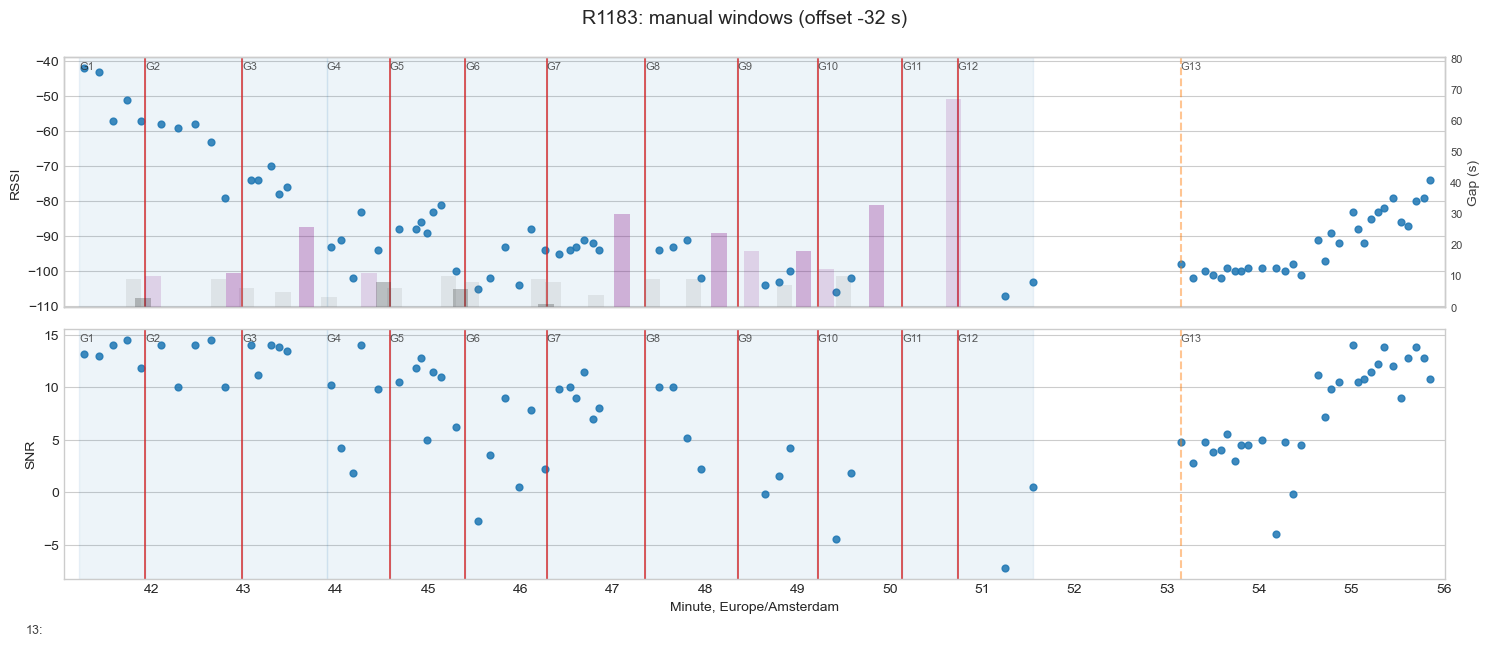

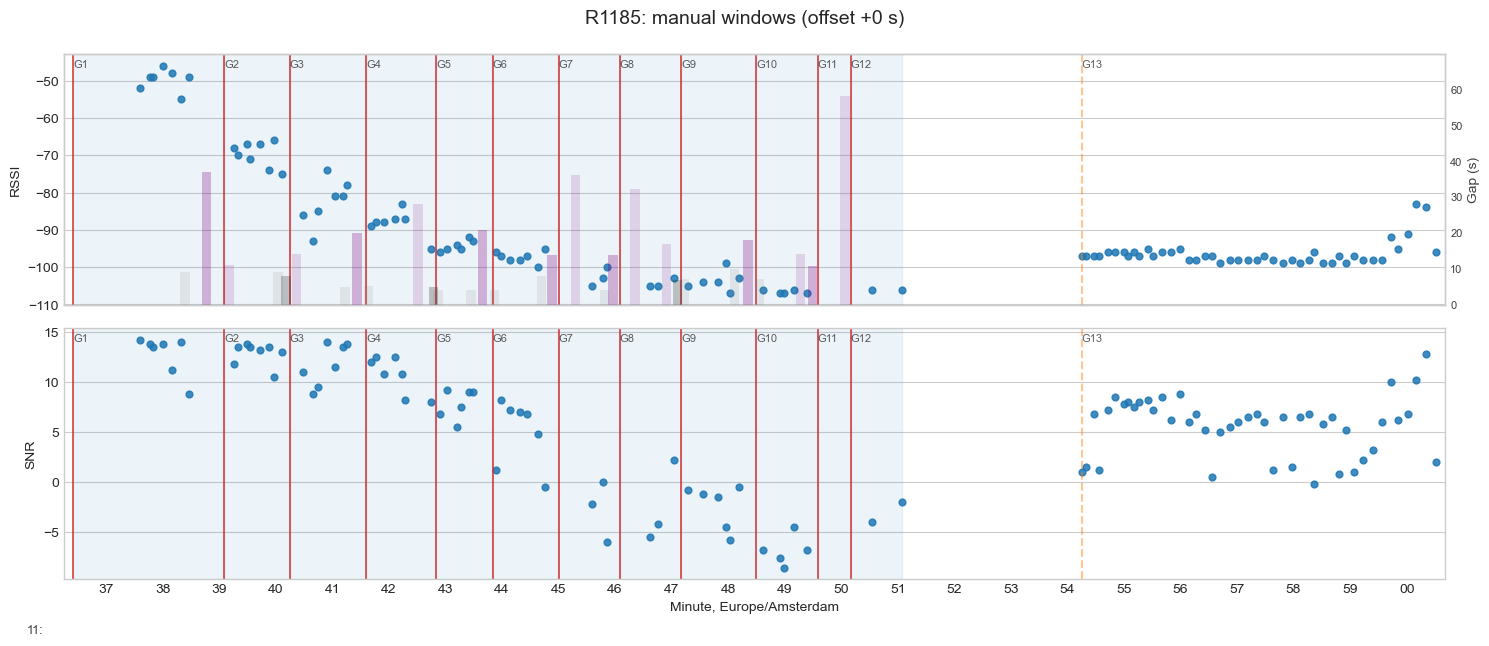

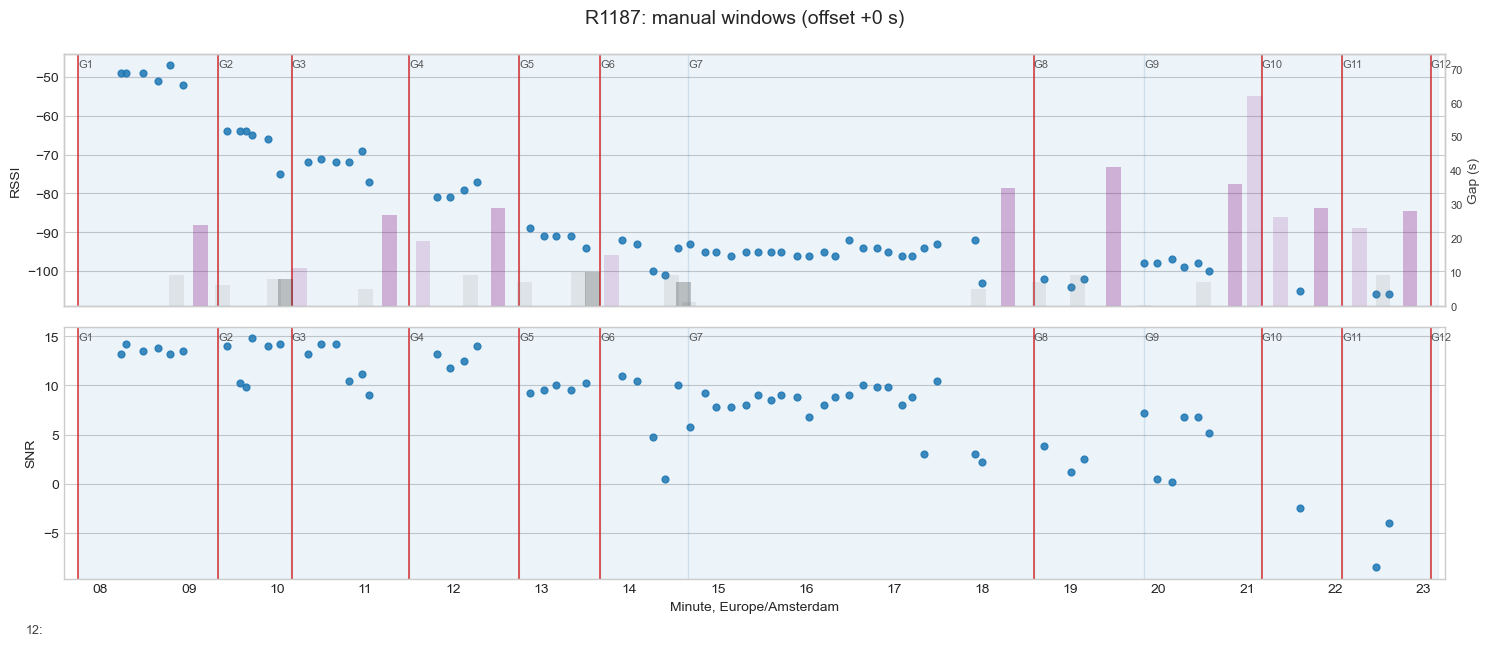

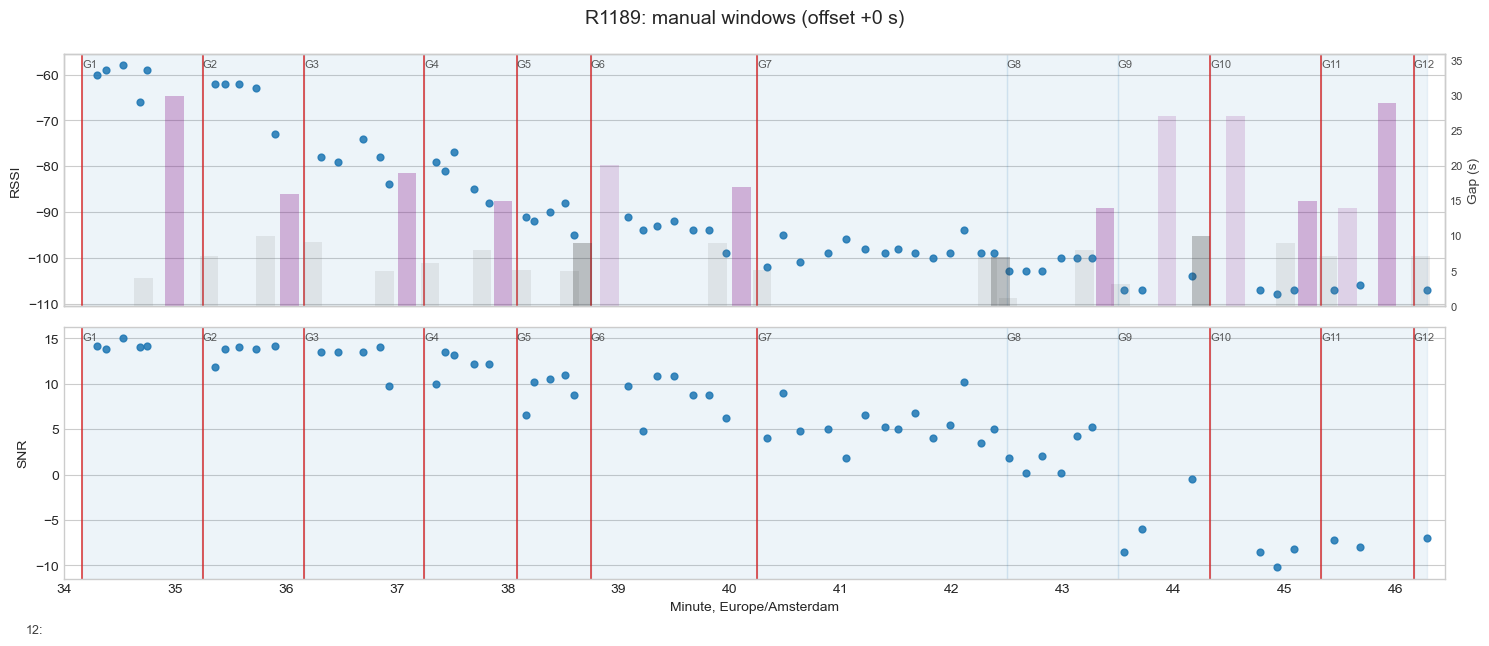

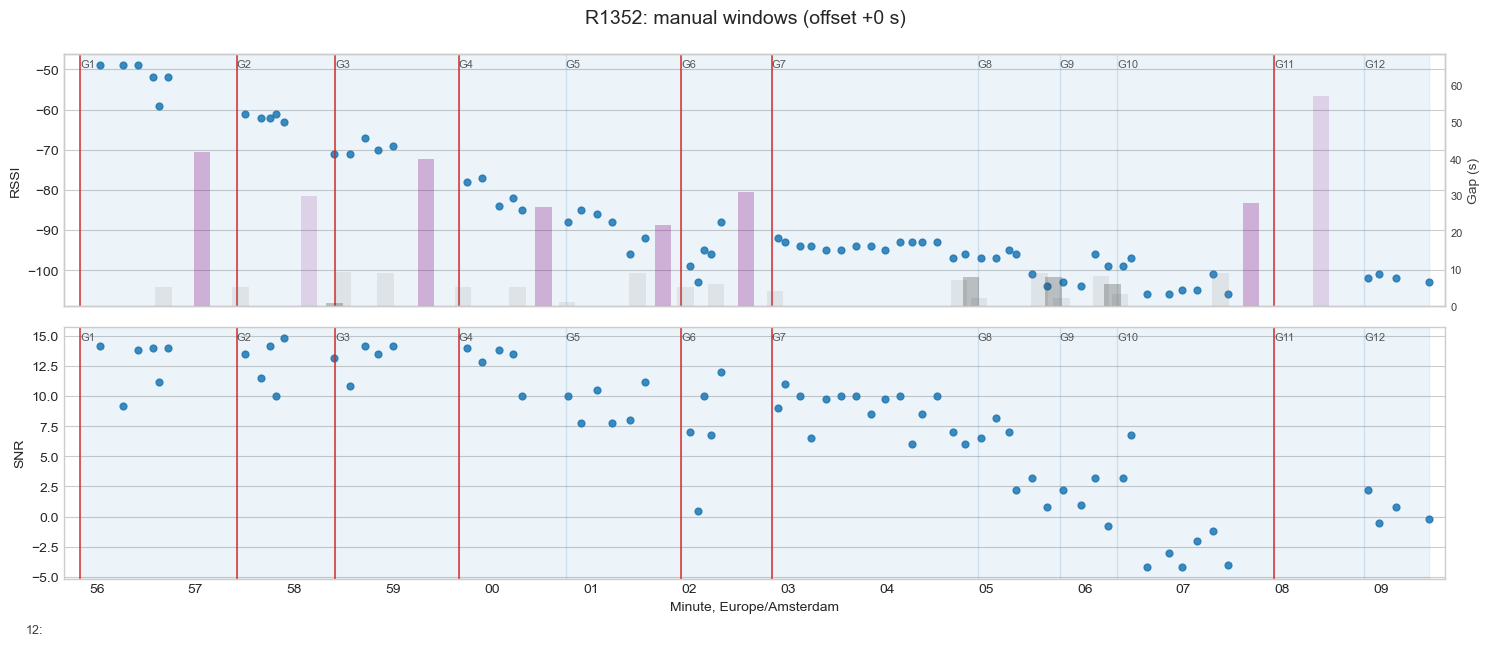

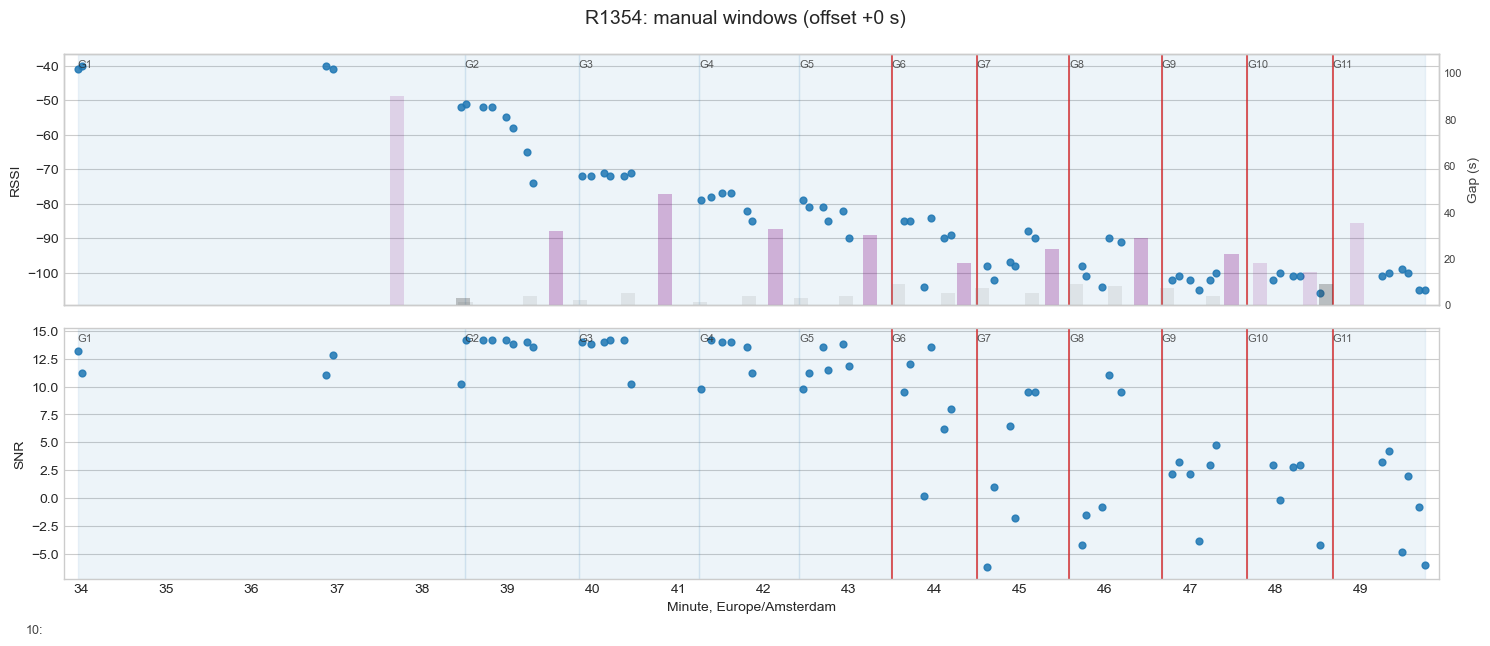

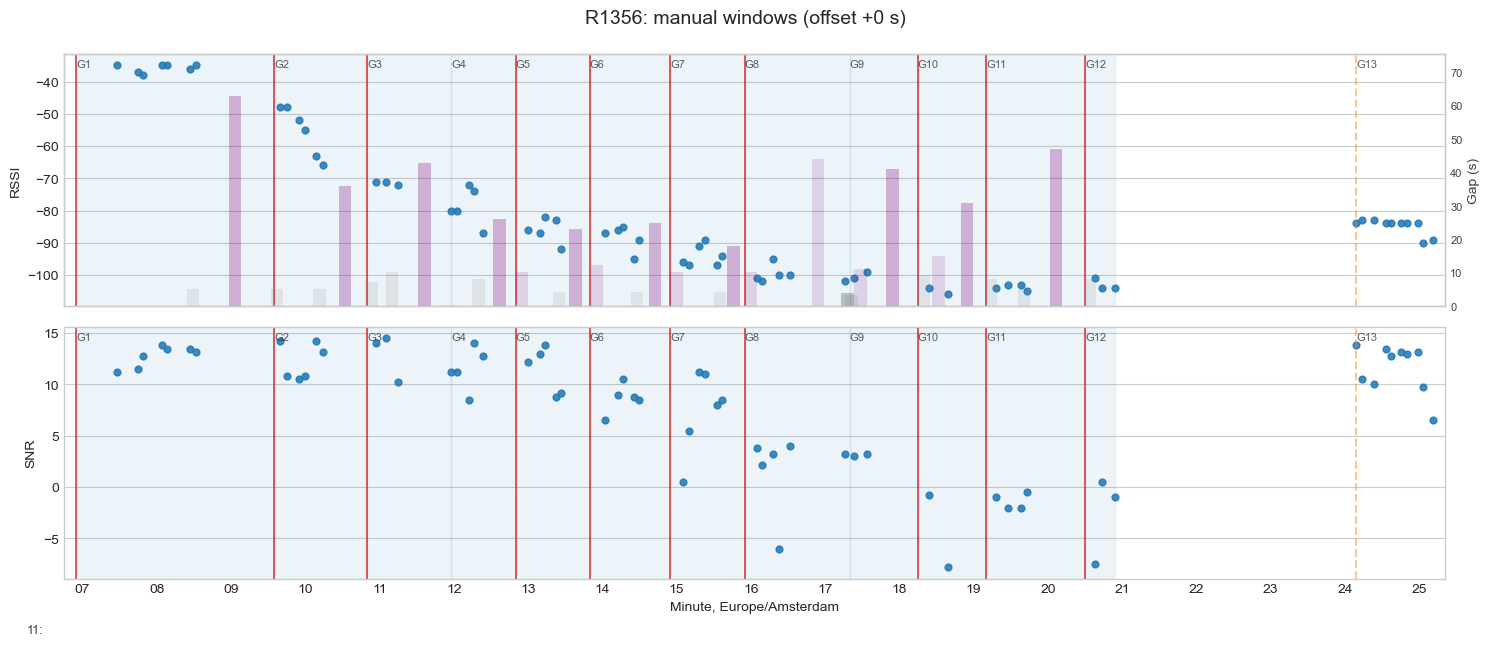

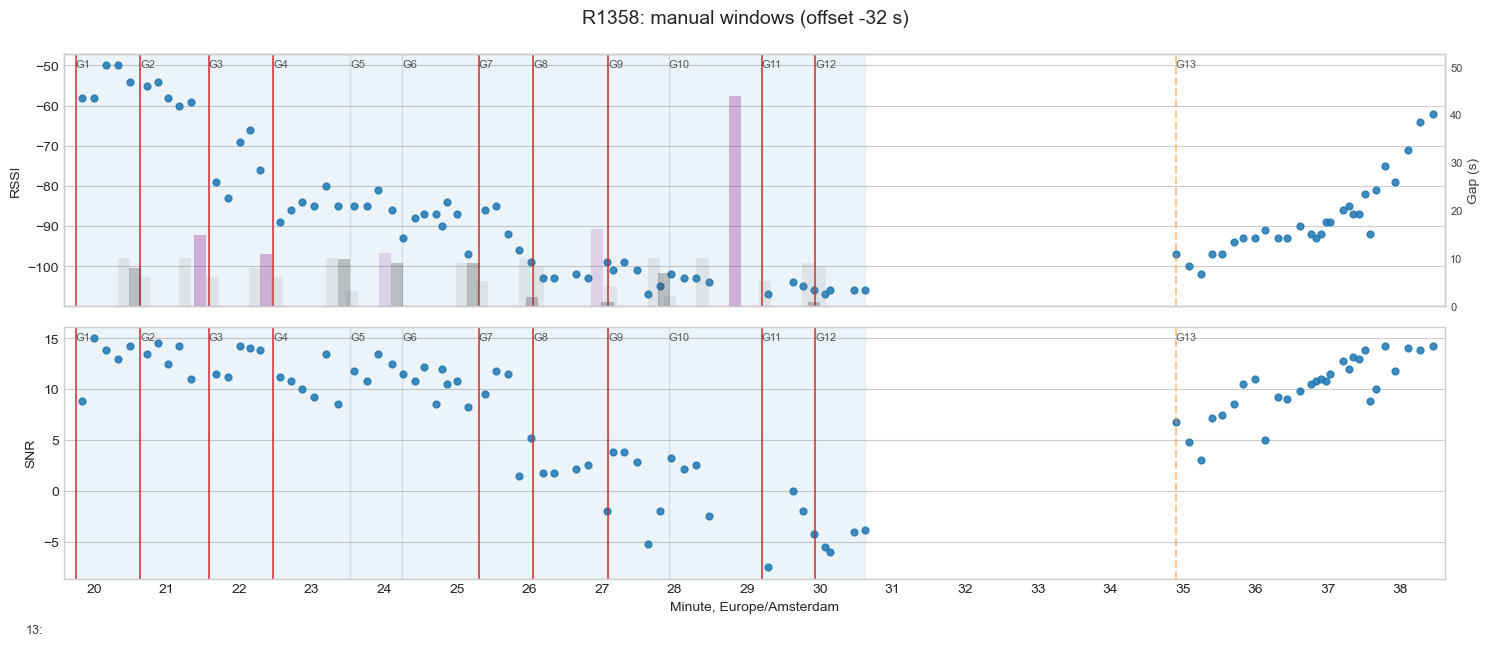

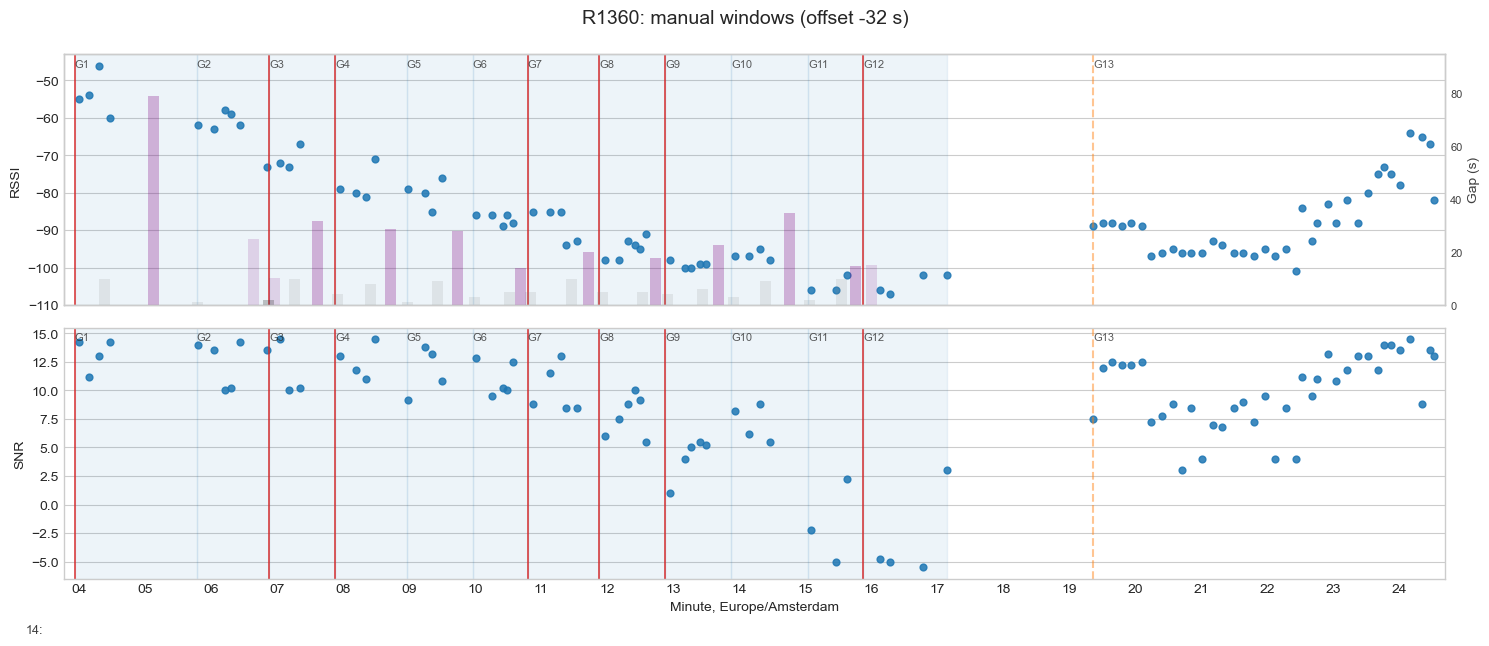

,dataset,original_rows,reloaded_rows,row_count_ok
0,clean_data,538,538,True
1,clean_extra_tail_data,151,151,True
2,combined_saved_data,689,689,True


In [139]:
# ---- Reload saved files and verify they can be plotted again ----

PLOT_RELOADED_DATA = True  # Replot from the CSVs written above to verify the reload path.


def load_clean_csv(path: Path) -> pd.DataFrame:
    """Load one saved clean-data CSV and restore the important dtypes."""
    if not path.exists() or path.stat().st_size == 0:
        return pd.DataFrame()
    loaded = pd.read_csv(path)

    datetime_cols = [
        "time", "time_local", "registered_start_time",
        "interval_start_time", "interval_end_time",
    ]
    for col in datetime_cols:
        if col in loaded.columns:
            loaded[col] = pd.to_datetime(loaded[col], errors="coerce")

    if "manual_group" in loaded.columns:
        loaded["manual_group"] = loaded["manual_group"].astype("Int64")
    for col in ["manual_group_reliable", "is_extra_tail_group", "is_final_group"]:
        if col in loaded.columns:
            loaded[col] = loaded[col].fillna(False).astype(bool)
    return loaded


clean_data_reloaded = load_clean_csv(clean_data_path)
clean_extra_tail_data_reloaded = load_clean_csv(clean_extra_tail_path)
saved_mapped_data_reloaded = pd.concat(
    [clean_data_reloaded, clean_extra_tail_data_reloaded],
    ignore_index=True,
    sort=False,
)

reload_validation_report = pd.DataFrame([
    {"dataset": "clean_data", "original_rows": len(clean_data), "reloaded_rows": len(clean_data_reloaded)},
    {"dataset": "clean_extra_tail_data", "original_rows": len(clean_extra_tail_data), "reloaded_rows": len(clean_extra_tail_data_reloaded)},
    {"dataset": "combined_saved_data", "original_rows": len(clean_data) + len(clean_extra_tail_data), "reloaded_rows": len(saved_mapped_data_reloaded)},
])
reload_validation_report["row_count_ok"] = reload_validation_report["original_rows"].eq(reload_validation_report["reloaded_rows"])

if PLOT_RELOADED_DATA and not saved_mapped_data_reloaded.empty:
    for structure_id in sorted(saved_mapped_data_reloaded["structure_id"].dropna().unique()):
        plot_manual_timeseries(saved_mapped_data_reloaded, structure_id)

reload_validation_report


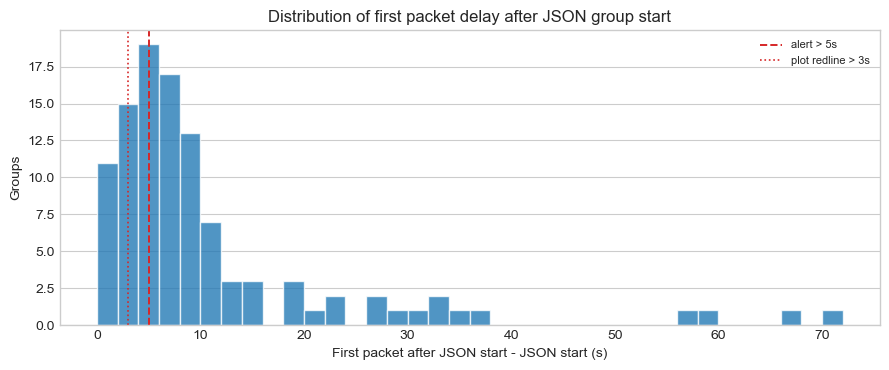

(    structure_id  manual_group           json_start_time       nearest_packet_time  nearest_delta_s  nearest_abs_delta_s first_packet_at_or_after_start  first_after_delta_s  \
 0          R1181             1 2026-06-25 14:46:46+02:00                       NaT              NaN                  NaN                            NaT                  NaN   
 1          R1181             2 2026-06-25 14:46:55+02:00                       NaT              NaN                  NaN                            NaT                  NaN   
 2          R1181             3 2026-06-25 14:47:47+02:00                       NaT              NaN                  NaN                            NaT                  NaN   
 3          R1181             4 2026-06-25 14:48:40+02:00                       NaT              NaN                  NaN                            NaT                  NaN   
 4          R1181             5 2026-06-25 14:49:12+02:00                       NaT              NaN               

In [140]:
# ---- How close is each JSON group start to an actual data point? ----

JSON_START_FIRST_POINT_ALERT_SECONDS = 5


def group_start_alignment_report(points: pd.DataFrame, group_starts: pd.DataFrame) -> pd.DataFrame:
    """Compare each non-tail JSON start with the first packet registered in that same start window."""
    measured = points[
        points["type"].astype(str).str.contains("Up", case=False, na=False)
        & points["time_local"].notna()
    ].copy()
    rows = []

    starts = group_starts[
        ~group_starts["is_extra_tail_group"]
        & group_starts["registered_start_time"].notna()
        & group_starts["start_time"].notna()
        & group_starts["valid_end"].notna()
    ].copy()
    starts = starts.sort_values(["structure_id", "registered_start_time"]).copy()
    starts["json_start_order"] = starts.groupby("structure_id", dropna=False).cumcount() + 1

    for _, rr in starts.iterrows():
        structure_id = rr["structure_id"]
        group = int(rr["manual_group"])
        json_start_order = int(rr["json_start_order"])
        json_start = rr["registered_start_time"]
        structure_points = measured[measured["structure_id"] == structure_id].sort_values("time_local")

        nearest_time = pd.NaT
        nearest_delta_s = np.nan
        first_after_time = pd.NaT
        first_after_delta_s = np.nan

        if not structure_points.empty:
            deltas_s = (structure_points["time_local"] - json_start).dt.total_seconds()
            nearest_idx = deltas_s.abs().idxmin()
            nearest_time = structure_points.loc[nearest_idx, "time_local"]
            nearest_delta_s = float(deltas_s.loc[nearest_idx])

            same_window = structure_points[
                (structure_points["time_local"] >= rr["start_time"])
                & (structure_points["time_local"] < rr["valid_end"])
            ].sort_values("time_local")
            if "is_extra_tail_group" in same_window.columns:
                same_window = same_window[~same_window["is_extra_tail_group"].fillna(False)]
            if "manual_group_reliable" in same_window.columns:
                same_window = same_window[same_window["manual_group_reliable"].fillna(False)]

            after = same_window[same_window["time_local"] >= json_start]
            if not after.empty:
                first_after_time = after["time_local"].iloc[0]
                first_after_delta_s = float((first_after_time - json_start).total_seconds())

        first_after_missing = pd.isna(first_after_time)
        first_after_late = pd.notna(first_after_delta_s) and first_after_delta_s > JSON_START_FIRST_POINT_ALERT_SECONDS
        first_after_alert = bool(first_after_missing or first_after_late)
        first_after_status = (
            "missing_after_json_start" if first_after_missing
            else f"later_than_{JSON_START_FIRST_POINT_ALERT_SECONDS}s" if first_after_late
            else "ok"
        )

        rows.append({
            "structure_id": structure_id,
            "manual_group": group,
            "json_start_order": json_start_order,
            "json_start_time": json_start,
            "nearest_packet_time": nearest_time,
            "nearest_delta_s": nearest_delta_s,
            "nearest_abs_delta_s": abs(nearest_delta_s) if np.isfinite(nearest_delta_s) else np.nan,
            "first_packet_at_or_after_start": first_after_time,
            "first_after_delta_s": first_after_delta_s,
            "first_after_alert": first_after_alert,
            "first_after_status": first_after_status,
        })

    return pd.DataFrame(rows).sort_values(["structure_id", "json_start_order"]).reset_index(drop=True)


json_start_alignment_report = group_start_alignment_report(mapped_data, mapping_windows)

json_start_alignment_summary = (
    json_start_alignment_report.groupby("structure_id", dropna=False)
    .agg(
        groups=("manual_group", "count"),
        median_abs_nearest_delta_s=("nearest_abs_delta_s", "median"),
        max_abs_nearest_delta_s=("nearest_abs_delta_s", "max"),
        median_first_after_delta_s=("first_after_delta_s", "median"),
        max_first_after_delta_s=("first_after_delta_s", "max"),
        first_after_alerts=("first_after_alert", "sum"),
    )
    .reset_index()
)

valid_start_deltas = json_start_alignment_report["first_after_delta_s"].dropna()

json_start_delta_descriptive_stats = valid_start_deltas.describe(
    percentiles=[0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
).to_frame(name="first_after_delta_s")
json_start_delta_descriptive_stats.loc["missing_after_json_start", "first_after_delta_s"] = json_start_alignment_report["first_packet_at_or_after_start"].isna().sum()
json_start_delta_descriptive_stats.loc["alerts_gt_5s_or_missing", "first_after_delta_s"] = json_start_alignment_report["first_after_alert"].sum()

json_start_delta_by_structure = (
    json_start_alignment_report.groupby("structure_id", dropna=False)
    .agg(
        groups=("manual_group", "count"),
        mean_first_after_delta_s=("first_after_delta_s", "mean"),
        median_first_after_delta_s=("first_after_delta_s", "median"),
        std_first_after_delta_s=("first_after_delta_s", "std"),
        p90_first_after_delta_s=("first_after_delta_s", lambda s: s.dropna().quantile(0.90) if not s.dropna().empty else np.nan),
        max_first_after_delta_s=("first_after_delta_s", "max"),
        missing_after_json_start=("first_packet_at_or_after_start", lambda s: s.isna().sum()),
        alerts_gt_5s_or_missing=("first_after_alert", "sum"),
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 3.8))
if valid_start_deltas.empty:
    ax.text(0.5, 0.5, "No first-after-start deltas available", ha="center", va="center", transform=ax.transAxes)
else:
    bins = np.arange(0, max(10, np.ceil(valid_start_deltas.max()) + 2), 2)
    ax.hist(valid_start_deltas, bins=bins, color="tab:blue", alpha=0.78, edgecolor="white")
    ax.axvline(JSON_START_FIRST_POINT_ALERT_SECONDS, color="tab:red", linestyle="--", linewidth=1.4, label=f"alert > {JSON_START_FIRST_POINT_ALERT_SECONDS}s")
    ax.axvline(JSON_START_PLOT_REDLINE_SECONDS, color="tab:red", linestyle=":", linewidth=1.2, label=f"plot redline > {JSON_START_PLOT_REDLINE_SECONDS}s")
    ax.legend(fontsize=8)
ax.set_title("Distribution of first packet delay after JSON group start")
ax.set_xlabel("First packet after JSON start - JSON start (s)")
ax.set_ylabel("Groups")
ax.grid(False, axis="x")
plt.tight_layout()
plt.show()

json_start_alignment_report, json_start_alignment_summary, json_start_delta_descriptive_stats, json_start_delta_by_structure


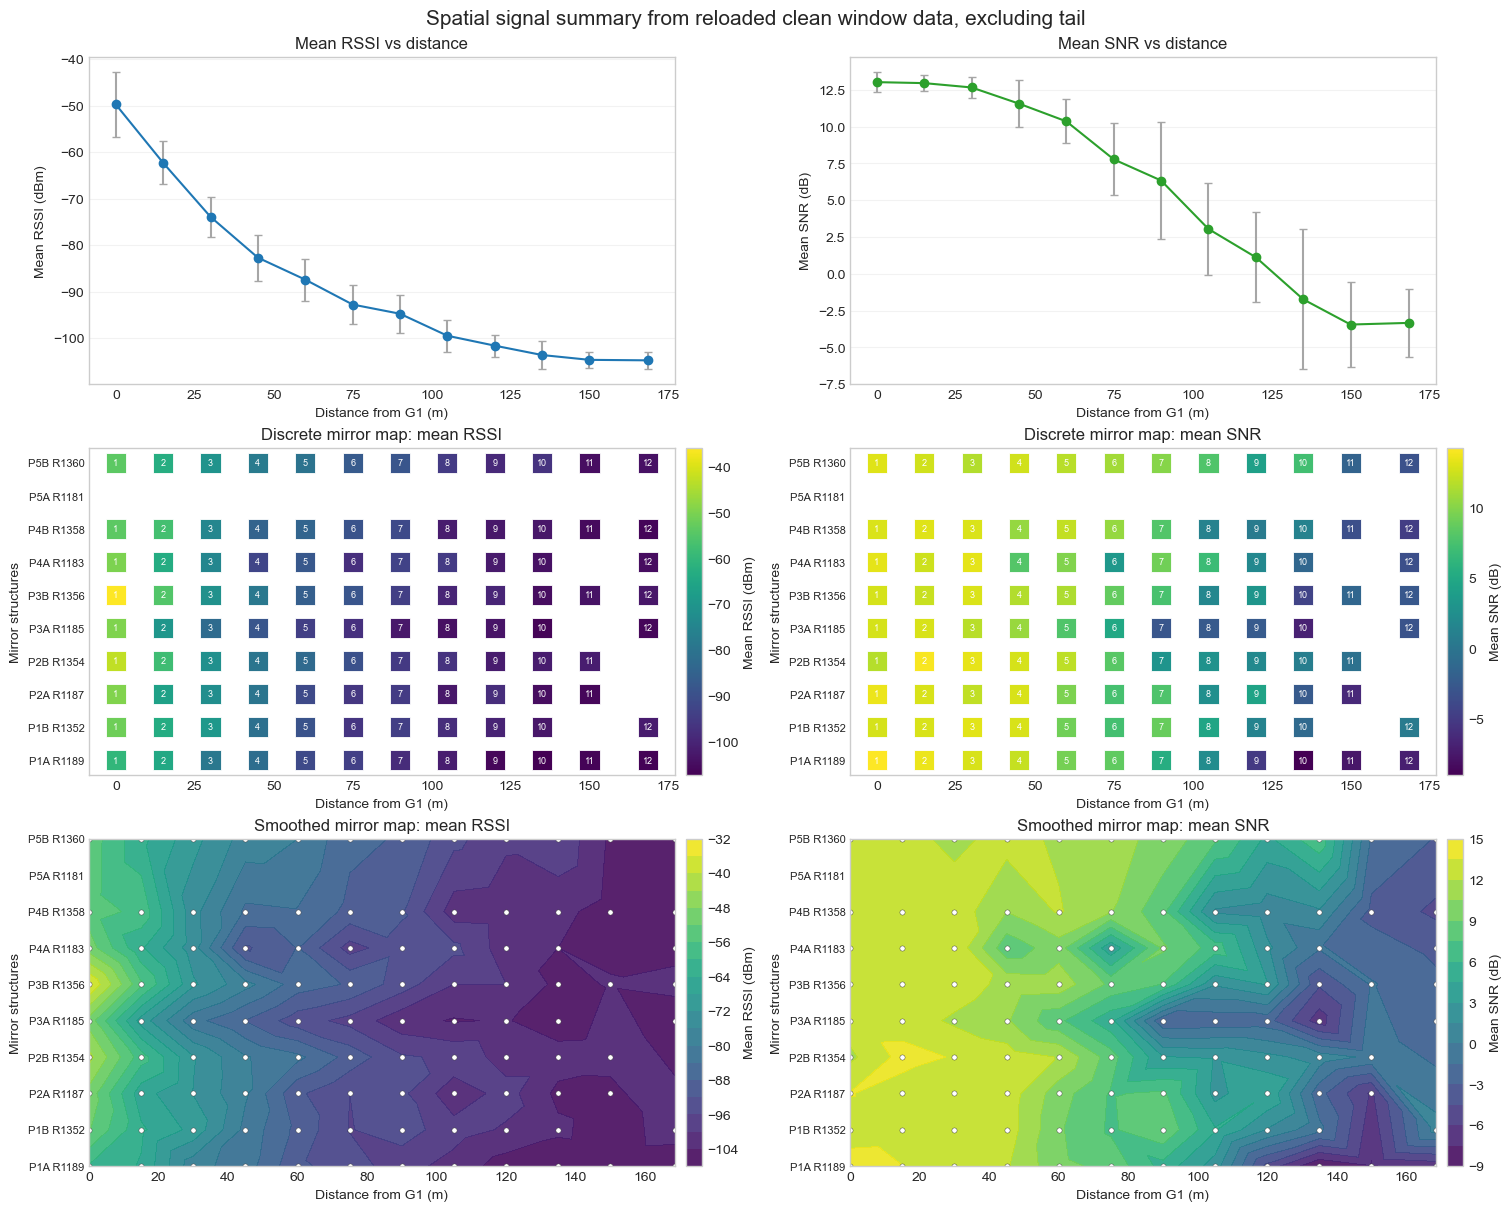

(    distance_m  groups  structures  samples   mean_rssi  std_rssi_between_structures   mean_snr  std_snr_between_structures
 0          0.0       1           9       50  -49.743122                     7.005341  13.019206                    0.697128
 1         15.0       1           9       54  -62.302910                     4.617476  12.952698                    0.538294
 2         30.0       1           9       44  -73.917196                     4.252616  12.657804                    0.692226
 3         45.0       1           9       47  -82.699206                     4.945698  11.559153                    1.611351
 4         60.0       1           9       48  -87.426720                     4.527609  10.354656                    1.502107
 5         75.0       1           9       54  -92.781614                     4.244352   7.774563                    2.439507
 6         90.0       1           9       82  -94.763781                     4.040962   6.337037                    3.995601


In [141]:
# ---- Spatial signal summaries: distance curves and mirror-structure heat maps ----


def group_to_plot_distance_m(group):
    """Positive plotting distance: G1 at 0 m, higher groups move to the right."""
    if pd.isna(group):
        return np.nan
    group = int(group)
    if group <= 12:
        distance_m = (group - 1) * 15
        if group == 12:
            distance_m += 3.5
        return distance_m
    # Extra tail/group 13 sits to the right of G12.
    return ((12 - 1) * 15 + 3.5) + (group - 12) * 15


def mirror_structure_layout(config: dict) -> pd.DataFrame:
    """Build one y-row per structure, keeping mirror pairs next to each other."""
    rows = []
    for pair_idx, pair in enumerate(config.get("mirror_structures", []), start=1):
        for side_idx, structure_id in enumerate(pair):
            rows.append({
                "structure_id": structure_id,
                "mirror_pair": pair_idx,
                "mirror_side": side_idx,
                "mirror_side_label": "A" if side_idx == 0 else "B",
                "y_mirror": (pair_idx - 1) * 2 + side_idx,
                "mirror_label": f"P{pair_idx}{'A' if side_idx == 0 else 'B'} {structure_id}",
            })
    return pd.DataFrame(rows)


mirror_layout = mirror_structure_layout(MANUAL_CONFIG)

# Use only normal-window clean data for spatial summaries and heat maps.
# Extra-tail rows are excluded because they are not part of the mapped windows.
if "clean_data_reloaded" in globals() and not clean_data_reloaded.empty:
    spatial_source = clean_data_reloaded.copy()
else:
    spatial_source = clean_data.copy()

spatial_source = spatial_source[spatial_source["manual_group"].notna()].copy()
spatial_source["distance_m"] = spatial_source["manual_group"].apply(group_to_plot_distance_m)
spatial_source = spatial_source[spatial_source["distance_m"].notna()].copy()

signal_by_structure_distance = (
    spatial_source.groupby(["structure_id", "manual_group", "distance_m"], dropna=False)
    .agg(
        samples=("rssi", "count"),
        mean_rssi=("rssi", "mean"),
        std_rssi=("rssi", "std"),
        mean_snr=("snr", "mean"),
        std_snr=("snr", "std"),
    )
    .reset_index()
    .merge(mirror_layout, on="structure_id", how="left")
)

signal_by_distance = (
    signal_by_structure_distance.groupby("distance_m", dropna=False)
    .agg(
        groups=("manual_group", "nunique"),
        structures=("structure_id", "nunique"),
        samples=("samples", "sum"),
        mean_rssi=("mean_rssi", "mean"),
        std_rssi_between_structures=("mean_rssi", "std"),
        mean_snr=("mean_snr", "mean"),
        std_snr_between_structures=("mean_snr", "std"),
    )
    .reset_index()
    .sort_values("distance_m")
)


def draw_distance_curve(ax, summary: pd.DataFrame, metric: str, ylabel: str, title: str, color: str):
    err_col = "std_rssi_between_structures" if metric == "mean_rssi" else "std_snr_between_structures"
    ax.errorbar(summary["distance_m"], summary[metric], yerr=summary[err_col], fmt="o-", color=color, ecolor="0.65", capsize=3)
    ax.set_xlabel("Distance from G1 (m)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, axis="y", alpha=0.25)
    ax.grid(False, axis="x")


def draw_discrete_heat(ax, summary: pd.DataFrame, metric: str, title: str):
    plot_data = summary.dropna(subset=["distance_m", "y_mirror", metric]).copy()
    sc = ax.scatter(
        plot_data["distance_m"],
        plot_data["y_mirror"],
        c=plot_data[metric],
        s=210,
        marker="s",
        cmap="viridis",
        edgecolor="white",
        linewidth=0.6,
    )
    for _, row in plot_data.iterrows():
        ax.text(row["distance_m"], row["y_mirror"], str(int(row["manual_group"])), ha="center", va="center", fontsize=6.5, color="white")
    ax.set_title(title)
    ax.set_xlabel("Distance from G1 (m)")
    ax.set_ylabel("Mirror structures")
    ax.grid(False)
    ax.set_yticks(mirror_layout["y_mirror"])
    ax.set_yticklabels(mirror_layout["mirror_label"], fontsize=8)
    return sc


def draw_smooth_heat(ax, summary: pd.DataFrame, metric: str, title: str):
    plot_data = summary.dropna(subset=["distance_m", "y_mirror", metric]).copy()
    if len(plot_data) < 4 or plot_data["distance_m"].nunique() < 2 or plot_data["y_mirror"].nunique() < 2:
        ax.text(0.5, 0.5, "Not enough points for smooth map", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(title)
        return None
    contour = ax.tricontourf(
        plot_data["distance_m"],
        plot_data["y_mirror"],
        plot_data[metric],
        levels=18,
        cmap="viridis",
        alpha=0.90,
    )
    ax.scatter(plot_data["distance_m"], plot_data["y_mirror"], s=14, c="white", edgecolor="0.2", linewidth=0.3)
    ax.set_title(title)
    ax.set_xlabel("Distance from G1 (m)")
    ax.set_ylabel("Mirror structures")
    ax.grid(False)
    ax.set_yticks(mirror_layout["y_mirror"])
    ax.set_yticklabels(mirror_layout["mirror_label"], fontsize=8)
    return contour


fig, axes = plt.subplots(3, 2, figsize=(15, 12), constrained_layout=True)

draw_distance_curve(axes[0, 0], signal_by_distance, "mean_rssi", "Mean RSSI (dBm)", "Mean RSSI vs distance", "tab:blue")
draw_distance_curve(axes[0, 1], signal_by_distance, "mean_snr", "Mean SNR (dB)", "Mean SNR vs distance", "tab:green")

rssi_sc = draw_discrete_heat(axes[1, 0], signal_by_structure_distance, "mean_rssi", "Discrete mirror map: mean RSSI")
snr_sc = draw_discrete_heat(axes[1, 1], signal_by_structure_distance, "mean_snr", "Discrete mirror map: mean SNR")

rssi_smooth = draw_smooth_heat(axes[2, 0], signal_by_structure_distance, "mean_rssi", "Smoothed mirror map: mean RSSI")
snr_smooth = draw_smooth_heat(axes[2, 1], signal_by_structure_distance, "mean_snr", "Smoothed mirror map: mean SNR")

for ax, mappable, label in [
    (axes[1, 0], rssi_sc, "Mean RSSI (dBm)"),
    (axes[1, 1], snr_sc, "Mean SNR (dB)"),
    (axes[2, 0], rssi_smooth, "Mean RSSI (dBm)"),
    (axes[2, 1], snr_smooth, "Mean SNR (dB)"),
]:
    if mappable is not None:
        cbar = fig.colorbar(mappable, ax=ax, pad=0.01)
        cbar.set_label(label)

fig.suptitle("Spatial signal summary from reloaded clean window data, excluding tail", fontsize=15)
plt.show()

signal_by_distance, signal_by_structure_distance
